In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import os

import clickhouse_connect

# Show all rows
pd.set_option("display.max_rows", None)

# Show all columns
pd.set_option("display.max_columns", None)

# Make sure wide DataFrames don't wrap
pd.set_option("display.width", None)

# Show the full content of each column (no '...')
pd.set_option("display.max_colwidth", None)

In [2]:
client = clickhouse_connect.get_client(
    host='yaujulxk39.eastus2.azure.clickhouse.cloud',      # or server IP
    port=8443,             # HTTP port (default)
    username='default',
    password='~gZjRLjjOJh1i',
    database='Competitive_Analysis'
)

In [3]:
# ---- Query ----
df_hum_hist = client.query_df("""
    SELECT *
    FROM Competitive_Analysis.DRGHistoricalReviewInformation
    WHERE Client = 'Hum'
""")
df_hum_hist.shape

(76355, 291)

In [4]:
# -------------------------------------------------
# Initial shape of the dataset
# -------------------------------------------------
df_hum = df_hum_hist.copy()

print(df_hum.shape)  

df_hum = df_hum[df_hum['InitialDenialType'] == 'Substantive']
print(df_hum.shape) 

# -------------------------------------------------
# Identify valid Group_Type values
# -------------------------------------------------

group_type_unique = df_hum['Group_Type'].dropna().unique()
print(group_type_unique) 

# -------------------------------------------------
# Filter dataset to only valid Group_Type rows
# Use .copy() to avoid SettingWithCopyWarning
# -------------------------------------------------
df_hum_group_type = df_hum[df_hum['Group_Type'].isin(group_type_unique)].copy()
print(df_hum_group_type.shape) 

# -------------------------------------------------
# Calculate ADRG length
# -------------------------------------------------
df_hum_group_type.loc[:, 'len_adrg'] = (
    df_hum_group_type['ADRG'].astype(str).str.len()
)

print(df_hum_group_type['len_adrg'].value_counts())
print(df_hum_group_type['Group_Type'].value_counts())

# -------------------------------------------------
# Remove invalid DRG / Group_Type combinations
#   1) Group_Type = '01' and ADRG length = 4
#   2) Group_Type = '10' and ADRG length = 3
# -------------------------------------------------
mask_remove = (
    ((df_hum_group_type['Group_Type'] == '01') & (df_hum_group_type['len_adrg'] == 4)) |
    ((df_hum_group_type['Group_Type'] == '10') & (df_hum_group_type['len_adrg'] == 3))
)

df_hum_drg_rem = df_hum_group_type.loc[~mask_remove].copy()
print(df_hum_drg_rem.shape)

# -------------------------------------------------
# Create a copy of InitialDeterminationDate
# -------------------------------------------------
df_hum_drg_rem.loc[:, 'InitialDeterminationDate_copy'] = (
    df_hum_drg_rem['InitialDeterminationDate']
)

print(
    df_hum_drg_rem['Control_ID']
    .value_counts()
    .sort_values(ascending=False)
    .head()
)

# -------------------------------------------------
# Convert date column to datetime
# -------------------------------------------------
df_hum_drg_rem.loc[:, 'InitialDeterminationDate_copy'] = pd.to_datetime(
    df_hum_drg_rem['InitialDeterminationDate_copy'],
    errors='coerce'
)

# -------------------------------------------------
# Keep latest record per Control_ID
# -------------------------------------------------
df_sorted = df_hum_drg_rem.sort_values(
    'InitialDeterminationDate_copy',
    ascending=False
)

df_hum_latest = df_sorted.drop_duplicates(
    subset='Control_ID',
    keep='first'
).copy()

print(df_hum_latest.shape)

# -------------------------------------------------
# Normalize string columns
# -------------------------------------------------
df_hum_latest.loc[:, 'ADRG'] = (
    df_hum_latest['ADRG'].astype(str).str.strip()
)

df_hum_latest.loc[:, 'PRIM_DX'] = (
    df_hum_latest['PRIM_DX'].astype(str).str.strip().str.upper()
)

df_hum_latest.loc[:, 'InitialDeterminationStatus'] = (
    df_hum_latest['InitialDeterminationStatus']
    .astype(str)
    .str.strip()
    .str.upper()
)

# -------------------------------------------------
# Clean numeric fields
# -------------------------------------------------
df_hum_latest.loc[:, 'IDSavings'] = (
    pd.to_numeric(df_hum_latest['IDSavings'], errors='coerce').fillna(0)
)

df_hum_latest.loc[:, 'LOS'] = (
    pd.to_numeric(df_hum_latest['LOS'], errors='coerce').fillna(0)
)

df_hum_latest.loc[:, 'AGE'] = (
    pd.to_numeric(df_hum_latest['AGE'], errors='coerce')
)

# -------------------------------------------------
# Validate AGE values
# -------------------------------------------------
max_age = df_hum_latest['AGE'].max()

df_hum_latest = df_hum_latest[(
    df_hum_latest['AGE'].between(0, max_age))
].copy()
df_hum_latest.loc[:, 'AGE'] = df_hum_latest['AGE'].astype('Int64')
print(df_hum_latest.shape)

# -------------------------------------------------
# Validate LOS values
# -------------------------------------------------
df_hum_latest.loc[:, 'LOS'] = (
    df_hum_latest['LOS'].astype('Int64')
)

df_hum_latest = df_hum_latest[(df_hum_latest['LOS'] >= 0)].copy()
print(df_hum_latest.shape)

# -------------------------------------------------
# Remove extreme savings outliers
# -------------------------------------------------
df_hum_latest = df_hum_latest[
    df_hum_latest['IDSavings'] < 650000
].reset_index(drop=True)

print(df_hum_latest.shape)

# Date only
df_hum_latest['InitialDeterminationDate_date'] = (
    df_hum_latest['InitialDeterminationDate'].dt.date
)

# Year
df_hum_latest['InitialDetermination_Year'] = (
    df_hum_latest['InitialDeterminationDate'].dt.year
)

df_hum_latest["InitialDeterminationDate_date"] = pd.to_datetime(
    df_hum_latest["InitialDeterminationDate_date"],
    errors="coerce"   # handles bad / empty values safely
)


df_hum_latest['InitialDeterminationStatus_Flag'] = (
    df_hum_latest['InitialDeterminationStatus']
    .str.strip()
    .str.upper()
    .map({
        'APPROVED': 0,
        'DENIED': 1
    })
)


df_hum_latest.shape

(76355, 291)
(76355, 291)
<StringArray>
['01', '10']
Length: 2, dtype: string
(76351, 291)
len_adrg
3    75215
4     1136
Name: count, dtype: int64
Group_Type
01    75214
10     1137
Name: count, dtype: Int64
(76340, 292)
Control_ID
HUPTMR-65573    1
HUPTMR-71671    1
HUPTMR-49129    1
HUPRMR-9433     1
HUPRMR-9418     1
Name: count, dtype: Int64
(76340, 293)
(76339, 293)
(76337, 293)
(76337, 293)


(76337, 296)

In [5]:
df_hum_ms_drg = df_hum_latest[df_hum_latest['Group_Type']=='01']
print(df_hum_ms_drg.shape)

df_hum_ms_drg['len_adrg'].value_counts()

(75206, 296)


len_adrg
3    75206
Name: count, dtype: int64

In [6]:
df = df_hum_ms_drg.copy()

adx_cols = [f"A_DX{i}" for i in range(2, 26)]
apx_cols = [f"A_PX{i}" for i in range(1, 26)]
bdx_cols = [f"B_DX{i}" for i in range(2, 26)]
bpx_cols = [f"B_PX{i}" for i in range(1, 26)]

df["A_DX_List"] = df[adx_cols].values.tolist()
df["A_PX_List"] = df[apx_cols].values.tolist()
df["B_DX_List"] = df[bdx_cols].values.tolist()
df["B_PX_List"] = df[bpx_cols].values.tolist()

# Convert to sorted comma separated values
df["A_DX_List"] = df["A_DX_List"].apply(lambda x: ",".join(sorted([str(i) for i in x if pd.notna(i)])))
df["A_PX_List"] = df["A_PX_List"].apply(lambda x: ",".join(sorted([str(i) for i in x if pd.notna(i)])))
df["B_DX_List"] = df["B_DX_List"].apply(lambda x: ",".join(sorted([str(i) for i in x if pd.notna(i)])))
df["B_PX_List"] = df["B_PX_List"].apply(lambda x: ",".join(sorted([str(i) for i in x if pd.notna(i)])))


def clean_sdx_list(val):
    if pd.isna(val) or val == "":
        return ""
    
    lst = val.split(",")  # split comma-separated values
    cleaned = []
    
    for item in lst:
        item = str(item).upper().strip()       # normalize
        item = item.replace("- MCC", "")       # remove MCC
        item = item.replace("- CC", "")        # remove CC
        item = item.replace("MCC", "")         # safety
        item = item.replace("CC", "")          # safety
        item = item.strip().replace("-", "")   # final cleanup
        cleaned.append(item)
    
    return ",".join(sorted(cleaned))  # sort again and join

df["A_DX_List_Clean"] = df["A_DX_List"].apply(clean_sdx_list)
df["B_DX_List_Clean"] = df["B_DX_List"].apply(clean_sdx_list)

mccandcclist_df = pd.read_excel(r"C:\Arun_MIX\MCCCCList.xlsx")
mccandcclist_df['ICDCode'] = (
    mccandcclist_df['ICDCode']
    .astype(str)
    .str.strip()
    .str.upper()
)
mccandcclist = dict(zip(mccandcclist_df['ICDCode'], mccandcclist_df['MCCorCC']))
print(f"✅ Loaded MCC/CC list with {len(mccandcclist)} entries.")

def map_sdx_types(icd_string, lookup_dict):

    if pd.isna(icd_string) or icd_string == "":
        return []

    icd_list = icd_string.split(",")

    cleaned_list = []
    for code in icd_list:
        code_clean = str(code).strip().upper()
        tag = lookup_dict.get(code_clean, "")
        cleaned_list.append(f"{code_clean} - {tag}")

    return cleaned_list


df['A_DX_Type_list'] = df['A_DX_List_Clean'].apply(lambda x: map_sdx_types(x, mccandcclist))
df['B_DX_Type_list'] = df['B_DX_List_Clean'].apply(lambda x: map_sdx_types(x, mccandcclist))


def split_dx_types(dx_list):

    mcc = [x.split(" - ")[0] for x in dx_list if "- MCC" in x]
    cc = [x.split(" - ")[0] for x in dx_list if "- CC" in x]
    general = [x.split(" - ")[0] for x in dx_list if "- MCC" not in x and "- CC" not in x]

    return pd.Series({
        "A_DX_MCC_Set": ",".join(sorted(mcc)),
        "A_DX_CC_Set": ",".join(sorted(cc)),
        "A_DX_General_Set": ",".join(sorted(general)),
        "A_DX_MCC_Count": len(mcc),
        "A_DX_CC_Count": len(cc),
        "A_DX_General_Count": len(general)
    })


df[[
    "A_DX_MCC_Set",
    "A_DX_CC_Set",
    "A_DX_General_Set",
    "A_DX_MCC_Count",
    "A_DX_CC_Count",
    "A_DX_General_Count"
]] = df["A_DX_Type_list"].apply(split_dx_types)

df.head(1)



✅ Loaded MCC/CC list with 17913 entries.


,Payor,claimid,Client,Control_ID,Claim_Number,PaymentType,Group_Type,Payments,Tax_ID,Provider_ID,HospitalName,LOS,DISP_Code,ADRG,DischargeYear,DischargeMonth,AGE,A_CCCount,A_MCCCount,B_CCCount,B_MCCCount,LOB,MRREQ,MRREC,PRIM_DX,A_DX2,A_DX3,A_DX4,A_DX5,A_DX6,A_DX7,A_DX8,A_DX9,A_DX10,A_DX11,A_DX12,A_DX13,A_DX14,A_DX15,A_DX16,A_DX17,A_DX18,A_DX19,A_DX20,A_DX21,A_DX22,A_DX23,A_DX24,A_DX25,A_POA,A_POA2,A_POA3,A_POA4,A_POA5,A_POA6,A_POA7,A_POA8,A_POA9,A_POA10,A_POA11,A_POA12,A_POA13,A_POA14,A_POA15,A_POA16,A_POA17,A_POA18,A_POA19,A_POA20,A_POA21,A_POA22,A_POA23,A_POA24,A_POA25,A_PX1,A_PX2,A_PX3,A_PX4,A_PX5,A_PX6,A_PX7,A_PX8,A_PX9,A_PX10,A_PX11,A_PX12,A_PX13,A_PX14,A_PX15,A_PX16,A_PX17,A_PX18,A_PX19,A_PX20,A_PX21,A_PX22,A_PX23,A_PX24,A_PX25,B_DISPCode,B_DenialCode,B_DRG,B_PRIMDX,B_DX2,B_DX3,B_DX4,B_DX5,B_DX6,B_DX7,B_DX8,B_DX9,B_DX10,B_DX11,B_DX12,B_DX13,B_DX14,B_DX15,B_DX16,B_DX17,B_DX18,B_DX19,B_DX20,B_DX21,B_DX22,B_DX23,B_DX24,B_DX25,B_POA,B_POA2,B_POA3,B_POA4,B_POA5,B_POA6,B_POA7,B_POA8,B_POA9,B_POA10,B_POA11,B_POA12,B_POA13,B_POA14,B_POA15,B_POA16,B_POA17,B_POA18,B_POA19,B_POA20,B_POA21,B_POA22,B_POA23,B_POA24,B_POA25,B_PX1,B_PX2,B_PX3,B_PX4,B_PX5,B_PX6,B_PX7,B_PX8,B_PX9,B_PX10,B_PX11,B_PX12,B_PX13,B_PX14,B_PX15,B_PX16,B_PX17,B_PX18,B_PX19,B_PX20,B_PX21,B_PX22,B_PX23,B_PX24,B_PX25,A_PRIMDX_Desc,A_DX2_Desc,A_DX3_Desc,A_DX4_Desc,A_DX5_Desc,A_DX6_Desc,A_DX7_Desc,A_DX8_Desc,A_DX9_Desc,A_DX10_Desc,A_DX11_Desc,A_DX12_Desc,A_DX13_Desc,A_DX14_Desc,A_DX15_Desc,A_DX16_Desc,A_DX17_Desc,A_DX18_Desc,A_DX19_Desc,A_DX20_Desc,A_DX21_Desc,A_DX22_Desc,A_DX23_Desc,A_DX24_Desc,A_DX25_Desc,A_PX1_Desc,A_PX2_Desc,A_PX3_Desc,A_PX4_Desc,A_PX5_Desc,A_PX6_Desc,A_PX7_Desc,A_PX8_Desc,A_PX9_Desc,A_PX10_Desc,A_PX11_Desc,A_PX12_Desc,A_PX13_Desc,A_PX14_Desc,A_PX15_Desc,A_PX16_Desc,A_PX17_Desc,A_PX18_Desc,A_PX19_Desc,A_PX20_Desc,A_PX21_Desc,A_PX22_Desc,A_PX23_Desc,A_PX24_Desc,A_PX25_Desc,B_PRIMDX_Desc,B_DX2_Desc,B_DX3_Desc,B_DX4_Desc,B_DX5_Desc,B_DX6_Desc,B_DX7_Desc,B_DX8_Desc,B_DX9_Desc,B_DX10_Desc,B_DX11_Desc,B_DX12_Desc,B_DX13_Desc,B_DX14_Desc,B_DX15_Desc,B_DX16_Desc,B_DX17_Desc,B_DX18_Desc,B_DX19_Desc,B_DX20_Desc,B_DX21_Desc,B_DX22_Desc,B_DX23_Desc,B_DX24_Desc,B_DX25_Desc,B_PX1_Desc,B_PX2_Desc,B_PX3_Desc,B_PX4_Desc,B_PX5_Desc,B_PX6_Desc,B_PX7_Desc,B_PX8_Desc,B_PX9_Desc,B_PX10_Desc,B_PX11_Desc,B_PX12_Desc,B_PX13_Desc,B_PX14_Desc,B_PX15_Desc,B_PX16_Desc,B_PX17_Desc,B_PX18_Desc,B_PX19_Desc,B_PX20_Desc,B_PX21_Desc,B_PX22_Desc,B_PX23_Desc,B_PX24_Desc,B_PX25_Desc,InitialDeterminationDate,InitialDenialType,InitialDeterminationStatus,IDSavings,AdjustedSavings,DXRemoved_AtoB,PRIMDX_DownCoded,InitialCoder,InitialCoder_Employer,InitialCoderID,InitialDoctor,InitialDoctorID,InitialProcessor,InitialProcessorID,len_adrg,InitialDeterminationDate_copy,InitialDeterminationDate_date,InitialDetermination_Year,InitialDeterminationStatus_Flag,A_DX_List,A_PX_List,B_DX_List,B_PX_List,A_DX_List_Clean,B_DX_List_Clean,A_DX_Type_list,B_DX_Type_list,A_DX_MCC_Set,A_DX_CC_Set,A_DX_General_Set,A_DX_MCC_Count,A_DX_CC_Count,A_DX_General_Count
0,Strat,1265742,Hum,HUPTMR-67499,820252450252252,PostPay,01,15464.79,455055149,455055149A,ST ANTHONY SHAWNEE HOSPITAL IN,7,01-ROUTINE/HOME,616,2025,8,52,7,3,7,3,MCD93,2025-11-19,NaT,E11621,G928 - MCC,Z5941,Z5982,Z5986,G9341 - MCC,L97419 - CC,M86171 - CC,M869 - CC,L02611 - CC,E88819,E1140,F3181 - CC,F1511,F1010,E039,I10,B1920,R45851 - CC,Z5900 - CC,E1165,F209,L97519,E1110 - MCC,Z794,Y,Y,<NA>,<NA>,<NA>,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,<NA>,Y,Y,Y,Y,<NA>,0Y6R0Z0,0JBQ0ZZ,0KBV0ZZ,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,01-ROUTINE/HOME,<NA>,616,E11621,G928 - MCC,Z5941,Z5982,Z5986,G9341 - MCC,L97419 - CC,M86171 - CC,M869 - CC,L02611 - CC,E88819,E1140,F3181 - CC,F1511,F1010,E039,I10,B1920,R45851 - CC,Z5900 - CC,E1165,F209,L97519,E1110 - MCC,Z794,Y,Y,<NA>,<NA>,<NA>,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,<NA>,Y,Y,Y,Y,<NA>,0Y6R0Z0,0JBQ0ZZ,0KBV0ZZ,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<N

In [7]:
df_with_sdx = df[~(df['A_DX_List'].notna() & (df['A_DX_List'].str.len() == 0))]
print(df_with_sdx.shape)

(73436, 310)


In [13]:
df_with_sdx = df_with_sdx[df_with_sdx['PaymentType']=='PostPay']
print(df_with_sdx.shape)

(64476, 310)


In [14]:
selected_cols = [
    "PaymentType","Payments","AGE","Provider_ID",
     "LOS", "ADRG", "PRIM_DX","A_DX_MCC_Set", "A_DX_CC_Set", "A_DX_General_Set","A_DX_MCC_Count",
     "A_DX_CC_Count","A_DX_General_Count","A_PX_List",
    "InitialDeterminationStatus"
]

df_new = df_with_sdx[selected_cols].copy()
df_new.shape

(64476, 15)

In [16]:
df_new["Status_binary"] = df_new["InitialDeterminationStatus"].str.strip().str.lower().map({
    "approved": 1,
    "denied": 0
})

df_new.head()

,PaymentType,Payments,AGE,Provider_ID,LOS,ADRG,PRIM_DX,A_DX_MCC_Set,A_DX_CC_Set,A_DX_General_Set,A_DX_MCC_Count,A_DX_CC_Count,A_DX_General_Count,A_PX_List,InitialDeterminationStatus,Status_binary
0,PostPay,15464.79,52,455055149A,7,616,E11621,"E1110,G928,G9341","F3181,L02611,L97419,M86171,M869,R45851","B1920,E039,E1140,E1165,E88819,F1010,F1511,F209,I10,L97519,Z5900,Z5941,Z5982,Z5986,Z794",3,6,15,"0JBQ0ZZ,0KBV0ZZ,0Y6R0Z0",APPROVED,1
1,PostPay,11699.99,85,566017737F,7,193,J189,"I5033,J9601",E873,"E039,E1165,E785,F0394,F419,I110,K219,K5900,K7469,Z1152,Z66,Z794,Z79890,Z79899,Z87440",2,1,15,"5A0945A,B32T1ZZ",APPROVED,1
2,PostPay,15543.60,71,900054201,6,377,K921,"J9601,N186","D62,I132,I5032,Z6841","D631,E1122,E6601,E66813,E785,E8351,G4733,I2510,I2720,I4891,J449,Z8673,Z955,Z992",2,4,14,"5A09357,5A1D70Z",APPROVED,1
4,PostPay,15628.23,67,160743102A,10,871,A419,"G9341,J189,J690,J9601,R532,R6521","E870,R64","D696,D72819,E119,E7800,E8339,E860,E861,E876,F0280,F79,G20A1,G40909,I959,J9809,N3281,R4182",6,2,16,"0BH17EZ,5A09357,5A1945Z",APPROVED,1
5,PostPay,11594.74,90,000198453,4,200,J95811,,"C3412,E440,E871","E1140,E1165,E7800,F17210,J449,N3020,N401,R338,R54,Z6821,Z7984,Z79899,Z8546,Z85828,Z86718,Z87442",0,3,16,"0BBG3ZX,0W9B30Z",APPROVED,1


# 3

Accuracy: 0.7334832506203474

Classification Report:

              precision    recall  f1-score   support

           0       0.28      0.73      0.40      1588
           1       0.95      0.73      0.83     11308

    accuracy                           0.73     12896
   macro avg       0.61      0.73      0.61     12896
weighted avg       0.87      0.73      0.78     12896


Confusion Matrix:

                     Predicted 0  Predicted 1
Actual 0 (Denied)           1152          436
Actual 1 (Approved)         3001         8307


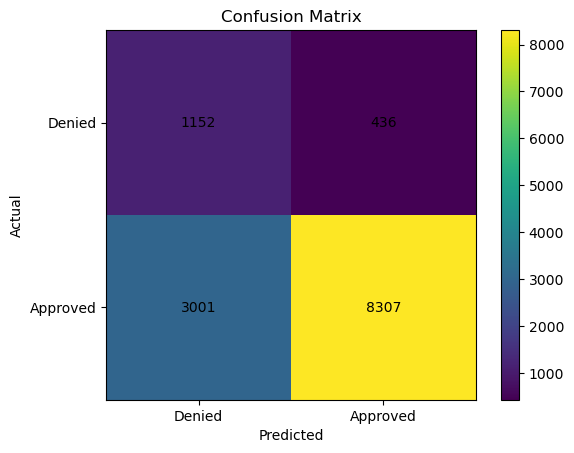

In [44]:
# ============================================================
# 🔥 1️⃣ IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix

# ============================================================
# 🔥 2️⃣ COPY DATA
# ============================================================
df = df_new.copy()

# ============================================================
# 🔥 3️⃣ CLEAN MULTI-VALUE STRING COLUMNS
# ============================================================
multi_cols = [
    'A_DX_MCC_Set',
    'A_DX_CC_Set',
    'A_DX_General_Set',
    'A_PX_List'
]

for col in multi_cols:
    df[col] = df[col].fillna('')

# ============================================================
# 🔥 4️⃣ TF-IDF ENCODING
# ============================================================
tfidf_features = []

for col in multi_cols:
    tfidf = TfidfVectorizer(
        tokenizer=lambda x: x.split(','),
        token_pattern=None,
        max_features=500
    )
    
    X_tfidf = tfidf.fit_transform(df[col])
    tfidf_features.append(X_tfidf)

X_tfidf_all = hstack(tfidf_features)

# ============================================================
# 🔥 5️⃣ BASIC FEATURES
# ============================================================
num_cols = ['Payments', 'AGE', 'LOS']
cat_cols = ['ADRG', 'PRIM_DX']

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

X_basic = df[num_cols + cat_cols] \
    .apply(pd.to_numeric, errors='coerce') \
    .fillna(0) \
    .astype(float) \
    .values

X_basic_sparse = csr_matrix(X_basic)

# ============================================================
# 🔥 6️⃣ FINAL MATRIX
# ============================================================
X_final = hstack([X_basic_sparse, X_tfidf_all])
y = df['Status_binary']

# ============================================================
# 🔥 7️⃣ TRAIN TEST SPLIT
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42, stratify=y
)

# ============================================================
# 🔥 8️⃣ RANDOM FOREST (IMBALANCE HANDLING)
# ============================================================
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=18,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight={0: 7, 1: 1},   # 🔥 focus on Denied (0)
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# ============================================================
# 🔥 9️⃣ PROBABILITY + THRESHOLD TUNING
# ============================================================
y_probs = model.predict_proba(X_test)[:, 1]

# 🔥 IMPORTANT: increase threshold → catch more denied
threshold = 0.55
y_pred = (y_probs > threshold).astype(int)

# ============================================================
# 🔥 🔟 EVALUATION
# ============================================================
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ============================================================
# 🔥 1️⃣1️⃣ CONFUSION MATRIX TABLE
# ============================================================
cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=['Actual 0 (Denied)', 'Actual 1 (Approved)'],
    columns=['Predicted 0', 'Predicted 1']
)

print("\nConfusion Matrix:\n")
print(cm_df)

# ============================================================
# 🔥 1️⃣2️⃣ CONFUSION MATRIX GRAPH
# ============================================================
plt.figure()
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ['Denied', 'Approved'])
plt.yticks([0, 1], ['Denied', 'Approved'])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.colorbar()
plt.show()

# 1

In [24]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

# =========================
# 1️⃣ LOAD DATA
# =========================
df = df_new.copy()

# =========================
# 2️⃣ HANDLE MULTI VALUE COLS
# =========================
multi_cols = [
    'A_DX_MCC_Set',
    'A_DX_CC_Set',
    'A_DX_General_Set',
    'A_PX_List'
]

for col in multi_cols:
    df[col] = df[col].fillna('')
    
    # count of codes
    df[f'{col}_count'] = df[col].apply(lambda x: len(x.split(',')) if x != '' else 0)
    
    # unique count
    #df[f'{col}_unique_count'] = df[col].apply(lambda x: len(set(x.split(','))) if x != '' else 0)

In [26]:
# =========================
# 3️⃣ GLOBAL FREQUENCY ENCODING
# =========================
def build_freq_map(series):
    freq = {}
    for row in series:
        if row == '':
            continue
        for code in row.split(','):
            freq[code] = freq.get(code, 0) + 1
    return freq

def encode_freq(row, freq_map):
    if row == '':
        return 0
    return np.mean([freq_map.get(code, 0) for code in row.split(',')])

for col in multi_cols:
    freq_map = build_freq_map(df[col])
    df[f'{col}_freq'] = df[col].apply(lambda x: encode_freq(x, freq_map))

In [27]:
df.head()

,PaymentType,Payments,AGE,Provider_ID,LOS,ADRG,PRIM_DX,A_DX_MCC_Set,A_DX_CC_Set,A_DX_General_Set,A_DX_MCC_Count,A_DX_CC_Count,A_DX_General_Count,A_PX_List,InitialDeterminationStatus,Status_binary,A_DX_MCC_Set_count,A_DX_CC_Set_count,A_DX_General_Set_count,A_PX_List_count,A_DX_MCC_Set_freq,A_DX_CC_Set_freq,A_DX_General_Set_freq,A_PX_List_freq
0,PostPay,15464.79,52,455055149A,7,616,E11621,"E1110,G928,G9341","F3181,L02611,L97419,M86171,M869,R45851","B1920,E039,E1140,E1165,E88819,F1010,F1511,F209,I10,L97519,Z5900,Z5941,Z5982,Z5986,Z794",3,6,15,"0JBQ0ZZ,0KBV0ZZ,0Y6R0Z0",APPROVED,1,3,6,15,3,3673.0,215.333333,3605.133333,53.333333
1,PostPay,11699.99,85,566017737F,7,193,J189,"I5033,J9601",E873,"E039,E1165,E785,F0394,F419,I110,K219,K5900,K7469,Z1152,Z66,Z794,Z79890,Z79899,Z87440",2,1,15,"5A0945A,B32T1ZZ",APPROVED,1,2,1,15,2,8235.5,1242.000000,9017.133333,361.000000
2,PostPay,15543.60,71,900054201,6,377,K921,"J9601,N186","D62,I132,I5032,Z6841","D631,E1122,E6601,E66813,E785,E8351,G4733,I2510,I2720,I4891,J449,Z8673,Z955,Z992",2,4,14,"5A09357,5A1D70Z",APPROVED,1,2,4,14,2,10026.0,4926.250000,8665.285714,7530.500000
4,PostPay,15628.23,67,160743102A,10,871,A419,"G9341,J189,J690,J9601,R532,R6521","E870,R64","D696,D72819,E119,E7800,E8339,E860,E861,E876,F0280,F79,G20A1,G40909,I959,J9809,N3281,R4182",6,2,16,"0BH17EZ,5A09357,5A1945Z",APPROVED,1,6,2,16,3,5556.0,2459.500000,3209.500000,3269.333333
5,PostPay,11594.74,90,000198453,4,200,J95811,,"C3412,E440,E871","E1140,E1165,E7800,F17210,J449,N3020,N401,R338,R54,Z6821,Z7984,Z79899,Z8546,Z85828,Z86718,Z87442",0,3,16,"0BBG3ZX,0W9B30Z",APPROVED,1,0,3,16,2,0.0,4770.000000,4584.062500,278.500000


In [28]:
# =========================
# 4️⃣ LABEL ENCODING
# =========================
cat_cols = ['ADRG', 'PRIM_DX']

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

# =========================
# 5️⃣ FEATURE SELECTION
# =========================
feature_cols = [
    'Payments', 'AGE', 'LOS',
    'ADRG', 'PRIM_DX'
]

# add engineered cols
for col in multi_cols:
    feature_cols += [
        f'{col}_count',
       # f'{col}_unique_count',
        f'{col}_freq'
    ]

X = df[feature_cols]
y = df['Status_binary']

In [29]:
# =========================
# 6️⃣ TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# 7️⃣ RANDOM FOREST MODEL
# =========================
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=12,
                       min_samples_leaf=5, min_samples_split=10,
                       n_estimators=200, n_jobs=-1, random_state=42)

In [30]:
# =========================
# 8️⃣ PREDICTION
# =========================
y_pred = model.predict(X_test)

# =========================
# 9️⃣ EVALUATION
# =========================
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8324286600496278
              precision    recall  f1-score   support

           0       0.39      0.62      0.48      1588
           1       0.94      0.86      0.90     11308

    accuracy                           0.83     12896
   macro avg       0.66      0.74      0.69     12896
weighted avg       0.87      0.83      0.85     12896



In [31]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=['Actual 0 (Denied)', 'Actual 1 (Approved)'],
    columns=['Predicted 0', 'Predicted 1']
)

print(cm_df)

                     Predicted 0  Predicted 1
Actual 0 (Denied)            979          609
Actual 1 (Approved)         1552         9756


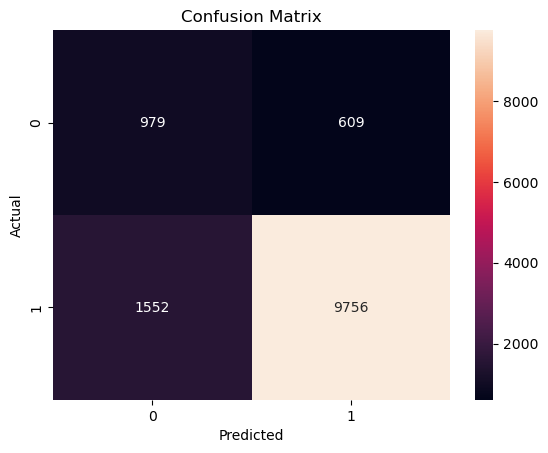

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

In [33]:
# =========================
# 🔟 FEATURE IMPORTANCE
# =========================
feat_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

print(feat_imp.head(20))

                   feature  importance
4                  PRIM_DX    0.269913
3                     ADRG    0.223957
6        A_DX_MCC_Set_freq    0.083133
12          A_PX_List_freq    0.065723
0                 Payments    0.059633
5       A_DX_MCC_Set_count    0.053642
11         A_PX_List_count    0.051760
8         A_DX_CC_Set_freq    0.041055
2                      LOS    0.038643
10   A_DX_General_Set_freq    0.037608
1                      AGE    0.034296
9   A_DX_General_Set_count    0.022511
7        A_DX_CC_Set_count    0.018124


# 2

Accuracy: 0.8847704714640199

Classification Report:

              precision    recall  f1-score   support

           0       0.54      0.39      0.46      1588
           1       0.92      0.95      0.94     11308

    accuracy                           0.88     12896
   macro avg       0.73      0.67      0.70     12896
weighted avg       0.87      0.88      0.88     12896


Confusion Matrix Table:

                     Predicted 0  Predicted 1
Actual 0 (Denied)            624          964
Actual 1 (Approved)          522        10786


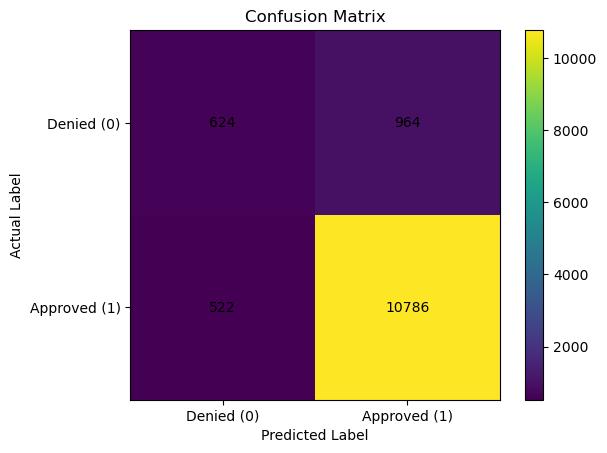


Top Features:

                   feature  importance
4                  PRIM_DX    0.204398
3                     ADRG    0.171586
11         A_PX_List_count    0.147119
5       A_DX_MCC_Set_count    0.135390
7        A_DX_CC_Set_count    0.061893
2                      LOS    0.056230
12          A_PX_List_freq    0.055777
6        A_DX_MCC_Set_freq    0.052415
0                 Payments    0.039209
9   A_DX_General_Set_count    0.021305
8         A_DX_CC_Set_freq    0.020214
10   A_DX_General_Set_freq    0.017549
1                      AGE    0.016916


In [36]:
# ============================================================
# 🔥 1️⃣ IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

from imblearn.over_sampling import SMOTE

# ============================================================
# 🔥 2️⃣ COPY DATA
# ============================================================
df = df_new.copy()

# ============================================================
# 🔥 3️⃣ MULTI-VALUE FEATURE ENGINEERING
# ============================================================
multi_cols = [
    'A_DX_MCC_Set',
    'A_DX_CC_Set',
    'A_DX_General_Set',
    'A_PX_List'
]

for col in multi_cols:
    df[col] = df[col].fillna('')

    # count only
    df[f'{col}_count'] = df[col].apply(lambda x: len(x.split(',')) if x != '' else 0)

# ============================================================
# 🔥 4️⃣ GLOBAL FREQUENCY ENCODING
# ============================================================
def build_freq_map(series):
    freq = {}
    for row in series:
        if row == '':
            continue
        for code in row.split(','):
            freq[code] = freq.get(code, 0) + 1
    return freq

def encode_freq(row, freq_map):
    if row == '':
        return 0
    return np.mean([freq_map.get(code, 0) for code in row.split(',')])

for col in multi_cols:
    freq_map = build_freq_map(df[col])
    df[f'{col}_freq'] = df[col].apply(lambda x: encode_freq(x, freq_map))

# ============================================================
# 🔥 5️⃣ LABEL ENCODING
# ============================================================
cat_cols = ['ADRG', 'PRIM_DX']

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

# ============================================================
# 🔥 6️⃣ FEATURE SELECTION
# ============================================================
feature_cols = [
    'Payments', 'AGE', 'LOS',
    'ADRG', 'PRIM_DX'
]

for col in multi_cols:
    feature_cols += [
        f'{col}_count',
        f'{col}_freq'
    ]

X = df[feature_cols]
y = df['Status_binary']

# ============================================================
# 🔥 7️⃣ CLEAN + FIX DATATYPES (CRITICAL)
# ============================================================
# convert everything to numeric → handle hidden issues
X = X.apply(pd.to_numeric, errors='coerce').fillna(0).astype(float)

# ============================================================
# 🔥 8️⃣ TRAIN TEST SPLIT
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ============================================================
# 🔥 9️⃣ SMOTE (IMBALANCE HANDLING)
# ============================================================
smote = SMOTE(sampling_strategy=0.4, random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# ============================================================
# 🔥 🔟 RANDOM FOREST MODEL
# ============================================================
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_sm, y_train_sm)

# ============================================================
# 🔥 1️⃣1️⃣ PREDICTION (WITH THRESHOLD)
# ============================================================
y_probs = model.predict_proba(X_test)[:, 1]

threshold = 0.35
y_pred = (y_probs > threshold).astype(int)

# ============================================================
# 🔥 1️⃣2️⃣ EVALUATION
# ============================================================
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ============================================================
# 🔥 1️⃣3️⃣ CONFUSION MATRIX TABLE
# ============================================================
cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=['Actual 0 (Denied)', 'Actual 1 (Approved)'],
    columns=['Predicted 0', 'Predicted 1']
)

print("\nConfusion Matrix Table:\n")
print(cm_df)

# ============================================================
# 🔥 1️⃣4️⃣ CONFUSION MATRIX GRAPH
# ============================================================
plt.figure()
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0, 1], ['Denied (0)', 'Approved (1)'])
plt.yticks([0, 1], ['Denied (0)', 'Approved (1)'])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

# ============================================================
# 🔥 1️⃣5️⃣ FEATURE IMPORTANCE
# ============================================================
feat_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

print("\nTop Features:\n")
print(feat_imp.head(20))

# Prev

In [10]:
df_new['Payments'].median()

10277.955

In [10]:
# ============================================================
# 🔥 BUSINESS RULE FEATURES
# ============================================================

# High Payment (> 12000)
df_new['High_Payment_Flag'] = (df_new['Payments'] > 12000).astype(int)

# High LOS (> 10 days)
df_new['High_LOS_Flag'] = (df_new['LOS'] >= 10).astype(int)

# MCC Present (if set is not empty)
df_new['MCC_Flag'] = df_new['A_DX_MCC_Set'].apply(lambda x: 1 if len(x) > 0 else 0)

df_new['HighPay_MCC'] = df_new['High_Payment_Flag'] * df_new['MCC_Flag']
df_new['HighLOS_MCC'] = df_new['High_LOS_Flag'] * df_new['MCC_Flag']
df_new['HighPay_HighLOS'] = df_new['High_Payment_Flag'] * df_new['High_LOS_Flag']

df_new.head()

,PaymentType,Payments,AGE,LOS,ADRG,PRIM_DX,A_DX_MCC_Set,A_DX_CC_Set,A_DX_General_Set,A_DX_MCC_Count,A_DX_CC_Count,A_DX_General_Count,InitialDeterminationStatus,Status_binary,High_Payment_Flag,High_LOS_Flag,MCC_Flag,HighPay_MCC,HighLOS_MCC,HighPay_HighLOS
0,PostPay,15464.79,52,7,616,E11621,"E1110,G928,G9341","F3181,L02611,L97419,M86171,M869,R45851","B1920,E039,E1140,E1165,E88819,F1010,F1511,F209,I10,L97519,Z5900,Z5941,Z5982,Z5986,Z794",3,6,15,APPROVED,1,1,0,1,1,0,0
1,PostPay,11699.99,85,7,193,J189,"I5033,J9601",E873,"E039,E1165,E785,F0394,F419,I110,K219,K5900,K7469,Z1152,Z66,Z794,Z79890,Z79899,Z87440",2,1,15,APPROVED,1,0,0,1,0,0,0
2,PostPay,15543.60,71,6,377,K921,"J9601,N186","D62,I132,I5032,Z6841","D631,E1122,E6601,E66813,E785,E8351,G4733,I2510,I2720,I4891,J449,Z8673,Z955,Z992",2,4,14,APPROVED,1,1,0,1,1,0,0
4,PostPay,15628.23,67,10,871,A419,"G9341,J189,J690,J9601,R532,R6521","E870,R64","D696,D72819,E119,E7800,E8339,E860,E861,E876,F0280,F79,G20A1,G40909,I959,J9809,N3281,R4182",6,2,16,APPROVED,1,1,1,1,1,1,1
5,PostPay,11594.74,90,4,200,J95811,,"C3412,E440,E871","E1140,E1165,E7800,F17210,J449,N3020,N401,R338,R54,Z6821,Z7984,Z79899,Z8546,Z85828,Z86718,Z87442",0,3,16,APPROVED,1,0,0,0,0,0,0


In [12]:
df = df_new.copy()

 # 3

In [19]:
# ============================================================
# 1️⃣ IMPORTS & SETUP
# ============================================================

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from torch_geometric.nn import GCNConv
import ast
from collections import defaultdict
import itertools

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================================
# 2️⃣ LOAD ICD EMBEDDINGS
# ============================================================

pretrained_embedding = pd.read_json(
    "hf://datasets/attuneengineering/ICD_10_Embedding_Collection/ICD_10_embedding_collection.json"
)

def norm_icd(x):
    return str(x).upper().replace('.', '').strip()

def safe_embedding(emb, dim=512):
    if isinstance(emb, list):
        arr = np.array(emb, dtype=np.float32)
        if arr.shape[0] == dim:
            return arr
    return np.zeros(dim, dtype=np.float32)

pretrained_embedding['id'] = pretrained_embedding['id'].astype(str).apply(norm_icd)
pretrained_embedding['embedding'] = pretrained_embedding['embedding'].apply(safe_embedding)

icd_embedding_map = dict(zip(pretrained_embedding['id'], pretrained_embedding['embedding']))

# ============================================================
# 3️⃣ HELPER FUNCTIONS
# ============================================================

def ensure_list(x):
    if isinstance(x, list):
        return x
    if pd.isna(x) or x == "":
        return []
    if isinstance(x, str) and x.startswith('['):
        try:
            return ast.literal_eval(x)
        except:
            return []
    if isinstance(x, str):
        return [i.strip() for i in x.split(',') if i.strip()]
    return []

# ============================================================
# 4️⃣ TRAIN TEST SPLIT
# ============================================================

train_df, test_df = train_test_split(
    df, test_size=0.2, stratify=df['Status_binary'], random_state=42
)

# ============================================================
# 5️⃣ CLEAN DATA
# ============================================================

for col in ['A_DX_MCC_Set','A_DX_CC_Set']:
    train_df[col] = train_df[col].apply(ensure_list)
    train_df[col] = train_df[col].apply(lambda x: [norm_icd(i) for i in x])

train_df['PRIM_DX'] = train_df['PRIM_DX'].apply(norm_icd)
train_df['ADRG'] = train_df['ADRG'].astype(str)

# ============================================================
# 6️⃣ BUILD SINGLE CO-OCCURRENCE GRAPH (ALL TOGETHER)
# ============================================================

def get_all_nodes(row):
    return list(set(
        [row['PRIM_DX']] +
        row['A_DX_MCC_Set'] +
        row['A_DX_CC_Set'] +
        [row['ADRG']]
    ))

cooc = defaultdict(int)

for _, row in train_df.iterrows():
    nodes = get_all_nodes(row)
    for i, j in itertools.combinations(nodes, 2):
        cooc[(i, j)] += 1
        cooc[(j, i)] += 1

# ============================================================
# 7️⃣ BUILD GRAPH
# ============================================================

def build_graph(cooc_dict, threshold=2):
    nodes = list(set([i for pair in cooc_dict for i in pair]))
    node2idx = {n:i for i,n in enumerate(nodes)}

    edge_index = []

    for (i, j), w in cooc_dict.items():
        if w >= threshold:
            edge_index.append([node2idx[i], node2idx[j]])

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    return nodes, node2idx, edge_index

nodes, node2idx, edge_index = build_graph(cooc)

# ============================================================
# 8️⃣ NODE FEATURES
# ============================================================

def get_embedding(node):
    if node in icd_embedding_map:
        return icd_embedding_map[node]
    else:
        return np.random.normal(0, 0.1, 512)

X = torch.tensor(np.array([get_embedding(n) for n in nodes]), dtype=torch.float).to(device)
edge_index = edge_index.to(device)

# ============================================================
# 9️⃣ GNN MODEL
# ============================================================

class GNN(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.conv1 = GCNConv(in_dim, 128)
        self.conv2 = GCNConv(128, 128)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x

# ============================================================
# 🔟 TRAIN GNN
# ============================================================

model_gnn = GNN(512).to(device)
optimizer = torch.optim.Adam(model_gnn.parameters(), lr=1e-3)

for epoch in range(15):
    model_gnn.train()
    optimizer.zero_grad()

    z = model_gnn(X, edge_index)
    src, dst = edge_index

    score = (z[src] * z[dst]).sum(dim=1)
    loss = -torch.log(torch.sigmoid(score)).mean()

    loss.backward()
    optimizer.step()

    print(f"GNN Epoch {epoch+1}, Loss: {loss.item():.4f}")

# ============================================================
# 1️⃣1️⃣ FINAL NODE EMBEDDINGS
# ============================================================

model_gnn.eval()
with torch.no_grad():
    final_emb = model_gnn(X, edge_index).cpu().numpy()

gnn_map = {nodes[i]: final_emb[i] for i in range(len(nodes))}

# ============================================================
# 1️⃣2️⃣ CLAIM LEVEL FEATURES
# ============================================================

def mean_emb(lst):
    embs = [gnn_map[i] for i in lst if i in gnn_map]
    if len(embs) == 0:
        return np.zeros(128)
    return np.mean(embs, axis=0)

def get_features(row):
    prim = gnn_map.get(row['PRIM_DX'], np.zeros(128))
    drg  = gnn_map.get(row['ADRG'], np.zeros(128))

    combined_dx = row['A_DX_MCC_Set'] + row['A_DX_CC_Set']
    dx_emb = mean_emb(combined_dx)

    # 🔥 NEW FEATURE
    mcc_present = 1 if len(row['A_DX_MCC_Set']) > 0 else 0

    return np.hstack([prim, dx_emb, drg, [mcc_present]])

train_df['gnn_feat'] = train_df.apply(get_features, axis=1)

# ============================================================
# 1️⃣3️⃣ FINAL DATASET
# ============================================================

num_cols = ['LOS','AGE','Payments']

X_num = train_df[num_cols].values
X_gnn = np.vstack(train_df['gnn_feat'].values)

# Scale numerical
scaler = StandardScaler()
X_num = scaler.fit_transform(X_num)

X_final = np.hstack([X_num, X_gnn])
y = train_df['Status_binary'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, stratify=y, random_state=42
)

GNN Epoch 1, Loss: 0.6448
GNN Epoch 2, Loss: 0.5895
GNN Epoch 3, Loss: 0.5091
GNN Epoch 4, Loss: 0.4072
GNN Epoch 5, Loss: 0.2946
GNN Epoch 6, Loss: 0.1897
GNN Epoch 7, Loss: 0.1089
GNN Epoch 8, Loss: 0.0577
GNN Epoch 9, Loss: 0.0299
GNN Epoch 10, Loss: 0.0160
GNN Epoch 11, Loss: 0.0090
GNN Epoch 12, Loss: 0.0054
GNN Epoch 13, Loss: 0.0034
GNN Epoch 14, Loss: 0.0023
GNN Epoch 15, Loss: 0.0016


# FOCAL 1   

In [20]:
# ============================================================
# 🚀 FULL TRAINING CELL (IMBALANCE HANDLING + TRAIN + EVAL)
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================================
# 1️⃣ CONVERT TO TENSORS
# ============================================================

X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)

X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

# ============================================================
# 2️⃣ FOCAL LOSS
# ============================================================

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        probs = torch.sigmoid(logits)

        pt = torch.where(targets == 1, probs, 1 - probs)
        focal_weight = self.alpha * (1 - pt) ** self.gamma

        return (focal_weight * bce).mean()

criterion = FocalLoss(alpha=0.75, gamma=2)

# ============================================================
# 3️⃣ WEIGHTED SAMPLER (HANDLE IMBALANCE)
# ============================================================

class_counts = np.bincount(y_train)
weights = 1. / class_counts
sample_weights = weights[y_train]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

dataset = TensorDataset(X_train_t, y_train_t)

loader = DataLoader(
    dataset,
    batch_size=256,
    sampler=sampler
)

# ============================================================
# 4️⃣ MODEL
# ============================================================

class ClaimModel(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze()

model = ClaimModel(X_train.shape[1]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ============================================================
# 5️⃣ TRAINING LOOP
# ============================================================

for epoch in range(15):
    model.train()
    total_loss = 0

    for xb, yb in loader:
        optimizer.zero_grad()

        logits = model(xb)
        loss = criterion(logits, yb)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

# ============================================================
# 6️⃣ EVALUATION + THRESHOLD TUNING
# ============================================================

model.eval()

with torch.no_grad():
    probs = torch.sigmoid(model(X_test_t)).cpu().numpy()

# 🔥 Try multiple thresholds
print("\n===== THRESHOLD TUNING =====")

for t in [0.3, 0.35, 0.4, 0.45, 0.5]:
    preds = (probs > t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, preds))

Epoch 1, Loss: 22.1802
Epoch 2, Loss: 21.6681
Epoch 3, Loss: 21.5794
Epoch 4, Loss: 21.4371
Epoch 5, Loss: 21.4329
Epoch 6, Loss: 21.3584
Epoch 7, Loss: 21.2184
Epoch 8, Loss: 21.1633
Epoch 9, Loss: 21.0945
Epoch 10, Loss: 21.1943
Epoch 11, Loss: 21.0227
Epoch 12, Loss: 21.0424
Epoch 13, Loss: 21.0731
Epoch 14, Loss: 21.0175
Epoch 15, Loss: 21.0899

===== THRESHOLD TUNING =====

Threshold: 0.3
              precision    recall  f1-score   support

           0       0.77      0.01      0.01      1410
           1       0.88      1.00      0.94     10340

    accuracy                           0.88     11750
   macro avg       0.82      0.50      0.48     11750
weighted avg       0.87      0.88      0.83     11750


Threshold: 0.35
              precision    recall  f1-score   support

           0       0.73      0.01      0.02      1410
           1       0.88      1.00      0.94     10340

    accuracy                           0.88     11750
   macro avg       0.80      0.51      0.


✅ Accuracy: 0.8809

📊 Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.01      0.02      1410
           1       0.88      1.00      0.94     10340

    accuracy                           0.88     11750
   macro avg       0.80      0.51      0.48     11750
weighted avg       0.86      0.88      0.83     11750



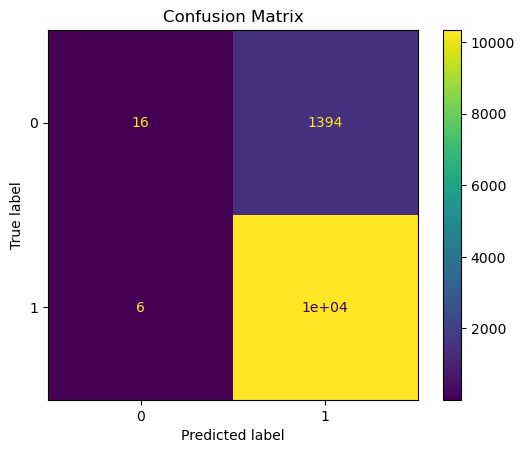

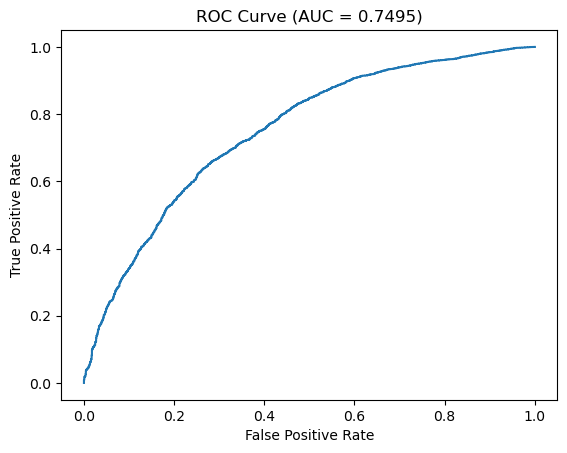

In [22]:
# ============================================================
# 1️⃣6️⃣ EVALUATION (FULL)
# ============================================================

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    roc_curve,
    auc
)

model.eval()

X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

with torch.no_grad():
    probs = torch.sigmoid(model(X_test_t)).cpu().numpy()

# Threshold tuning (you used 0.4)
preds = (probs > 0.35).astype(int)

# =========================
# ✅ Accuracy
# =========================
acc = accuracy_score(y_test, preds)
print(f"\n✅ Accuracy: {acc:.4f}")

# =========================
# 📊 Classification Report
# =========================
print("\n📊 Classification Report:\n")
print(classification_report(y_test, preds))

# =========================
# 🔥 Confusion Matrix
# =========================
cm = confusion_matrix(y_test, preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

# =========================
# 📈 ROC Curve
# =========================
fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {roc_auc:.4f})")
plt.show()

# FOCAL 2 -  HYBRID

In [23]:
# ============================================================
# 🚀 FULL OPTIMIZED TRAINING CELL (ALL IMPROVEMENTS)
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import classification_report, precision_recall_fscore_support

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================================
# 🎯 TARGET METRIC (CHANGE THIS BASED ON GOAL)
# ============================================================

TARGET = "recall_0"   # recall_0 / f1_0 / precision_0 / balanced

# ============================================================
# 1️⃣ CONVERT TO TENSORS
# ============================================================

X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)
X_test_t  = torch.tensor(X_test, dtype=torch.float32).to(device)

# ============================================================
# 2️⃣ HYBRID LOSS (FOCAL + WEIGHTED BCE)
# ============================================================

pos_weight = torch.tensor([(y_train==0).sum()/(y_train==1).sum()]).to(device)

class HybridLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2, pos_weight=None):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.pos_weight = pos_weight

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(
            logits, targets, reduction='none', pos_weight=self.pos_weight
        )
        probs = torch.sigmoid(logits)

        pt = torch.where(targets == 1, probs, 1 - probs)
        focal = self.alpha * (1 - pt) ** self.gamma

        return (focal * bce).mean()

criterion = HybridLoss(alpha=0.75, gamma=2, pos_weight=pos_weight)

# ============================================================
# 3️⃣ WEIGHTED SAMPLER
# ============================================================

class_counts = np.bincount(y_train)
weights = 1. / class_counts
sample_weights = weights[y_train]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

dataset = TensorDataset(X_train_t, y_train_t)

loader = DataLoader(
    dataset,
    batch_size=256,
    sampler=sampler
)

# ============================================================
# 4️⃣ IMPROVED MODEL
# ============================================================

class ClaimModel(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze()

model = ClaimModel(X_train.shape[1]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ============================================================
# 5️⃣ TRAINING
# ============================================================

for epoch in range(20):
    model.train()
    total_loss = 0

    for xb, yb in loader:
        optimizer.zero_grad()

        logits = model(xb)
        loss = criterion(logits, yb)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

# ============================================================
# 6️⃣ EVALUATION + AUTO THRESHOLD OPTIMIZATION
# ============================================================

model.eval()

with torch.no_grad():
    probs = torch.sigmoid(model(X_test_t)).cpu().numpy()

best_score = -1
best_threshold = 0.5

print("\n===== AUTO THRESHOLD SEARCH =====")

for t in np.arange(0.2, 0.7, 0.05):
    preds = (probs > t).astype(int)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, preds, average=None, zero_division=0
    )

    # class 0 metrics
    p0, r0, f0 = precision[0], recall[0], f1[0]

    if TARGET == "recall_0":
        score = r0
    elif TARGET == "precision_0":
        score = p0
    elif TARGET == "f1_0":
        score = f0
    else:  # balanced
        score = (f0 + f1[1]) / 2

    print(f"Threshold {t:.2f} | P0={p0:.2f} R0={r0:.2f} F0={f0:.2f}")

    if score > best_score:
        best_score = score
        best_threshold = t

# ============================================================
# 7️⃣ FINAL RESULT
# ============================================================

print(f"\n🔥 BEST THRESHOLD: {best_threshold:.2f} (Target={TARGET})")

final_preds = (probs > best_threshold).astype(int)

print("\n===== FINAL CLASSIFICATION REPORT =====")
print(classification_report(y_test, final_preds))

Epoch 1, Loss: 7.3331
Epoch 2, Loss: 6.9155
Epoch 3, Loss: 6.8843
Epoch 4, Loss: 6.8208
Epoch 5, Loss: 6.7906
Epoch 6, Loss: 6.7928
Epoch 7, Loss: 6.7903
Epoch 8, Loss: 6.7835
Epoch 9, Loss: 6.7289
Epoch 10, Loss: 6.7309
Epoch 11, Loss: 6.7272
Epoch 12, Loss: 6.6939
Epoch 13, Loss: 6.6760
Epoch 14, Loss: 6.6968
Epoch 15, Loss: 6.6700
Epoch 16, Loss: 6.6154
Epoch 17, Loss: 6.6840
Epoch 18, Loss: 6.6580
Epoch 19, Loss: 6.6087
Epoch 20, Loss: 6.5719

===== AUTO THRESHOLD SEARCH =====
Threshold 0.20 | P0=0.68 R0=0.04 F0=0.08
Threshold 0.25 | P0=0.41 R0=0.40 F0=0.40
Threshold 0.30 | P0=0.32 R0=0.52 F0=0.40
Threshold 0.35 | P0=0.24 R0=0.72 F0=0.36
Threshold 0.40 | P0=0.16 R0=0.92 F0=0.27
Threshold 0.45 | P0=0.14 R0=0.96 F0=0.25
Threshold 0.50 | P0=0.13 R0=0.98 F0=0.23
Threshold 0.55 | P0=0.12 R0=1.00 F0=0.22
Threshold 0.60 | P0=0.12 R0=1.00 F0=0.21
Threshold 0.65 | P0=0.12 R0=1.00 F0=0.21

🔥 BEST THRESHOLD: 0.55 (Target=recall_0)

===== FINAL CLASSIFICATION REPORT =====
              precisi


✅ Accuracy: 0.1249

📊 Classification Report:

              precision    recall  f1-score   support

           0       0.12      1.00      0.22      1410
           1       1.00      0.01      0.01     10340

    accuracy                           0.12     11750
   macro avg       0.56      0.50      0.11     11750
weighted avg       0.89      0.12      0.04     11750



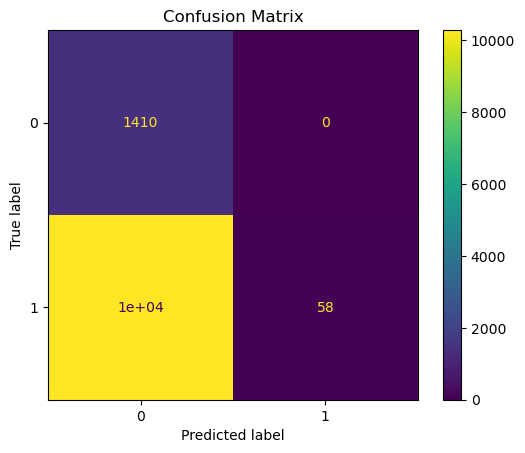

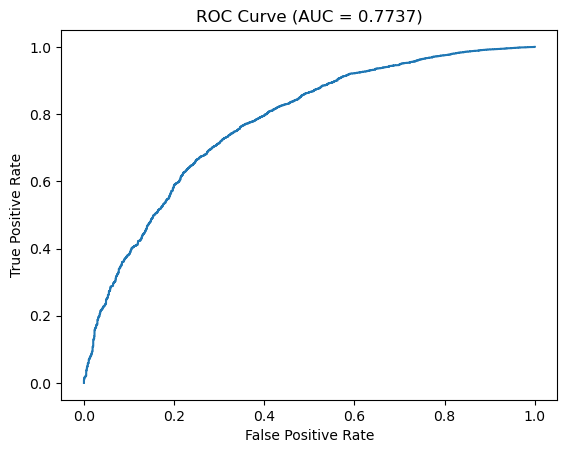

In [24]:
# ============================================================
# 1️⃣6️⃣ EVALUATION (FULL)
# ============================================================

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    roc_curve,
    auc
)

model.eval()

X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

with torch.no_grad():
    probs = torch.sigmoid(model(X_test_t)).cpu().numpy()

# Threshold tuning (you used 0.4)
preds = (probs > 0.55).astype(int)

# =========================
# ✅ Accuracy
# =========================
acc = accuracy_score(y_test, preds)
print(f"\n✅ Accuracy: {acc:.4f}")

# =========================
# 📊 Classification Report
# =========================
print("\n📊 Classification Report:\n")
print(classification_report(y_test, preds))

# =========================
# 🔥 Confusion Matrix
# =========================
cm = confusion_matrix(y_test, preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

# =========================
# 📈 ROC Curve
# =========================
fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {roc_auc:.4f})")
plt.show()

# F3

In [25]:
# ============================================================
# 🚀 BALANCED TRAINING (FIXED VERSION)
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================================
# 1️⃣ TENSORS
# ============================================================

X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)
X_test_t  = torch.tensor(X_test, dtype=torch.float32).to(device)

# ============================================================
# 2️⃣ FOCAL LOSS (NO POS_WEIGHT)
# ============================================================

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.6, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        probs = torch.sigmoid(logits)

        pt = torch.where(targets == 1, probs, 1 - probs)
        focal_weight = self.alpha * (1 - pt) ** self.gamma

        return (focal_weight * bce).mean()

criterion = FocalLoss(alpha=0.6, gamma=2)

# ============================================================
# 3️⃣ SAMPLER (LIGHT BALANCE)
# ============================================================

class_counts = np.bincount(y_train)
weights = 1. / np.sqrt(class_counts)   # 🔥 IMPORTANT CHANGE (less aggressive)

sample_weights = weights[y_train]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

dataset = TensorDataset(X_train_t, y_train_t)

loader = DataLoader(
    dataset,
    batch_size=256,
    sampler=sampler
)

# ============================================================
# 4️⃣ MODEL
# ============================================================

class ClaimModel(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze()

model = ClaimModel(X_train.shape[1]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ============================================================
# 5️⃣ TRAINING
# ============================================================

for epoch in range(20):
    model.train()
    total_loss = 0

    for xb, yb in loader:
        optimizer.zero_grad()

        logits = model(xb)
        loss = criterion(logits, yb)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")



Epoch 1, Loss: 14.8857
Epoch 2, Loss: 14.4976
Epoch 3, Loss: 14.4556
Epoch 4, Loss: 14.3210
Epoch 5, Loss: 14.6094
Epoch 6, Loss: 14.2759
Epoch 7, Loss: 14.2443
Epoch 8, Loss: 14.1522
Epoch 9, Loss: 14.1051
Epoch 10, Loss: 14.2049
Epoch 11, Loss: 14.1182
Epoch 12, Loss: 14.1449
Epoch 13, Loss: 13.9221
Epoch 14, Loss: 14.0668
Epoch 15, Loss: 14.0723
Epoch 16, Loss: 13.8761
Epoch 17, Loss: 13.9720
Epoch 18, Loss: 14.0102
Epoch 19, Loss: 13.9891
Epoch 20, Loss: 13.8739


In [27]:
# ============================================================
# 6️⃣ EVALUATION + AUTO THRESHOLD OPTIMIZATION
# ============================================================

model.eval()

with torch.no_grad():
    probs = torch.sigmoid(model(X_test_t)).cpu().numpy()

best_score = -1
best_threshold = 0.5

print("\n===== AUTO THRESHOLD SEARCH =====")

for t in np.arange(0.2, 0.7, 0.05):
    preds = (probs > t).astype(int)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, preds, average=None, zero_division=0
    )

    # class 0 metrics
    p0, r0, f0 = precision[0], recall[0], f1[0]

    if TARGET == "recall_0":
        score = r0
    elif TARGET == "precision_0":
        score = p0
    elif TARGET == "f1_0":
        score = f0
    else:  # balanced
        score = (f0 + f1[1]) / 2

    print(f"Threshold {t:.2f} | P0={p0:.2f} R0={r0:.2f} F0={f0:.2f}")

    if score > best_score:
        best_score = score
        best_threshold = t

# ============================================================
# 7️⃣ FINAL RESULT
# ============================================================

print(f"\n🔥 BEST THRESHOLD: {best_threshold:.2f} (Target={TARGET})")

final_preds = (probs > best_threshold).astype(int)

print("\n===== FINAL CLASSIFICATION REPORT =====")
print(classification_report(y_test, final_preds))


===== AUTO THRESHOLD SEARCH =====
Threshold 0.20 | P0=0.00 R0=0.00 F0=0.00
Threshold 0.25 | P0=0.00 R0=0.00 F0=0.00
Threshold 0.30 | P0=0.00 R0=0.00 F0=0.00
Threshold 0.35 | P0=0.75 R0=0.01 F0=0.02
Threshold 0.40 | P0=0.66 R0=0.04 F0=0.08
Threshold 0.45 | P0=0.54 R0=0.20 F0=0.30
Threshold 0.50 | P0=0.41 R0=0.41 F0=0.41
Threshold 0.55 | P0=0.37 R0=0.49 F0=0.42
Threshold 0.60 | P0=0.25 R0=0.70 F0=0.37
Threshold 0.65 | P0=0.18 R0=0.87 F0=0.29

🔥 BEST THRESHOLD: 0.65 (Target=recall_0)

===== FINAL CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.18      0.87      0.29      1410
           1       0.96      0.44      0.60     10340

    accuracy                           0.49     11750
   macro avg       0.57      0.66      0.45     11750
weighted avg       0.87      0.49      0.57     11750



In [36]:
# ============================================================
# 1️⃣6️⃣ EVALUATION
# ============================================================

model.eval()

X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

with torch.no_grad():
    probs = torch.sigmoid(model(X_test_t)).cpu().numpy()

preds = (probs > 0.56).astype(int)

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.35      0.52      0.42      1410
           1       0.93      0.87      0.90     10340

    accuracy                           0.83     11750
   macro avg       0.64      0.70      0.66     11750
weighted avg       0.86      0.83      0.84     11750




✅ Accuracy: 0.8284

📊 Classification Report:

              precision    recall  f1-score   support

           0       0.35      0.52      0.42      1410
           1       0.93      0.87      0.90     10340

    accuracy                           0.83     11750
   macro avg       0.64      0.70      0.66     11750
weighted avg       0.86      0.83      0.84     11750



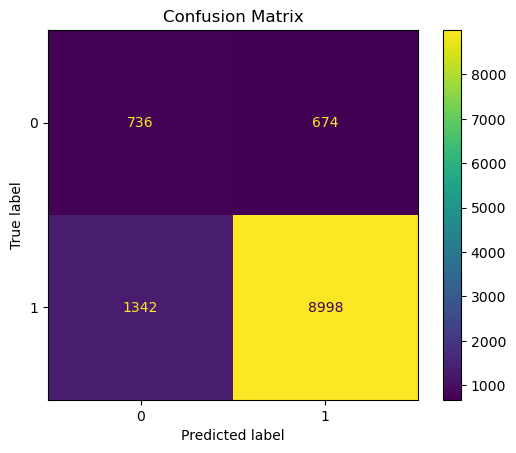

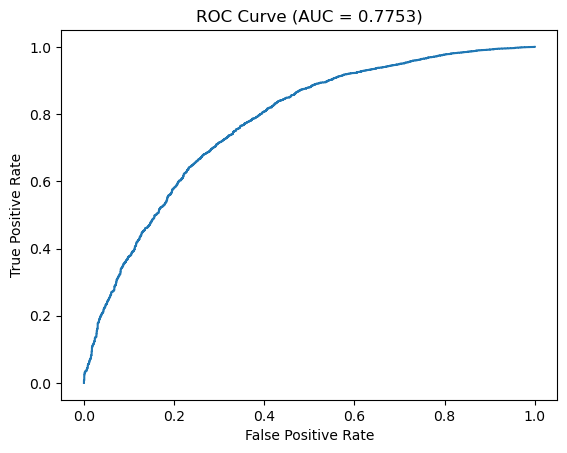

In [35]:
# ============================================================
# 1️⃣6️⃣ EVALUATION (FULL)
# ============================================================

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    roc_curve,
    auc
)

model.eval()

X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

with torch.no_grad():
    probs = torch.sigmoid(model(X_test_t)).cpu().numpy()

# Threshold tuning (you used 0.4)
preds = (probs > 0.56).astype(int)

# =========================
# ✅ Accuracy
# =========================
acc = accuracy_score(y_test, preds)
print(f"\n✅ Accuracy: {acc:.4f}")

# =========================
# 📊 Classification Report
# =========================
print("\n📊 Classification Report:\n")
print(classification_report(y_test, preds))

# =========================
# 🔥 Confusion Matrix
# =========================
cm = confusion_matrix(y_test, preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

# =========================
# 📈 ROC Curve
# =========================
fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {roc_auc:.4f})")
plt.show()

# xgb 1

In [37]:
# ============================================================
# 🔥 PRODUCTION PIPELINE: GNN + CLAIM FEATURES + IMBALANCE FIX
# ============================================================

# ============================================================
# 1️⃣ IMPORTS & SETUP
# ============================================================

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import ast
import itertools
import random

from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

from torch_geometric.nn import GCNConv
from torch_geometric.utils import negative_sampling
from xgboost import XGBClassifier

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================================
# 2️⃣ REPRODUCIBILITY (VERY IMPORTANT)
# ============================================================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# ============================================================
# 3️⃣ LOAD ICD EMBEDDINGS
# ============================================================

pretrained_embedding = pd.read_json(
    "hf://datasets/attuneengineering/ICD_10_Embedding_Collection/ICD_10_embedding_collection.json"
)

def norm_icd(x):
    return str(x).upper().replace('.', '').strip()

def safe_embedding(emb, dim=512):
    if isinstance(emb, list):
        arr = np.array(emb, dtype=np.float32)
        if arr.shape[0] == dim:
            return arr
    return np.zeros(dim, dtype=np.float32)

pretrained_embedding['id'] = pretrained_embedding['id'].astype(str).apply(norm_icd)
pretrained_embedding['embedding'] = pretrained_embedding['embedding'].apply(safe_embedding)

icd_embedding_map = dict(zip(pretrained_embedding['id'], pretrained_embedding['embedding']))

# ============================================================
# 4️⃣ HELPER FUNCTIONS
# ============================================================

def ensure_list(x):
    if isinstance(x, list): return x
    if pd.isna(x) or x == "": return []
    if isinstance(x, str) and x.startswith('['):
        try: return ast.literal_eval(x)
        except: return []
    if isinstance(x, str):
        return [i.strip() for i in x.split(',') if i.strip()]
    return []

# ============================================================
# 5️⃣ TRAIN TEST SPLIT
# ============================================================

train_df, test_df = train_test_split(
    df, test_size=0.2, stratify=df['Status_binary'], random_state=42
)

cols = ['A_DX_MCC_Set','A_DX_CC_Set']

for col in cols:
    train_df[col] = train_df[col].apply(ensure_list)
    train_df[col] = train_df[col].apply(lambda x: [norm_icd(i) for i in x])

train_df['PRIM_DX'] = train_df['PRIM_DX'].apply(norm_icd)
train_df['ADRG'] = train_df['ADRG'].astype(str)

# ============================================================
# 6️⃣ BUILD GRAPH (PRIM_DX + DRG + MCC + CC)
# ============================================================

def get_nodes(row):
    return list(set(
        [row['PRIM_DX']] +
        row['A_DX_MCC_Set'] +
        row['A_DX_CC_Set'] +
        [row['ADRG']]
    ))

cooc = defaultdict(int)

for _, row in train_df.iterrows():
    nodes = get_nodes(row)
    for i, j in itertools.combinations(nodes, 2):
        cooc[(i, j)] += 1
        cooc[(j, i)] += 1

nodes = list(set([i for pair in cooc for i in pair]))
node2idx = {n:i for i,n in enumerate(nodes)}

edge_index = []

for (i, j), w in cooc.items():
    if w >= 2:
        edge_index.append([node2idx[i], node2idx[j]])

edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous().to(device)

# ============================================================
# 7️⃣ NODE FEATURES (ICD + DRG)
# ============================================================

def get_embedding(node):
    if node in icd_embedding_map:
        return icd_embedding_map[node]
    return np.random.normal(0, 0.1, 512)

X = np.array([get_embedding(n) for n in nodes])
X = torch.tensor(X, dtype=torch.float).to(device)

# ============================================================
# 8️⃣ GNN MODEL
# ============================================================

class GNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(512, 128)
        self.conv2 = GCNConv(128, 128)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x

model_gnn = GNN().to(device)
optimizer = torch.optim.Adam(model_gnn.parameters(), lr=1e-3)

# ============================================================
# 9️⃣ TRAIN GNN (LINK PREDICTION)
# ============================================================

for epoch in range(15):
    model_gnn.train()
    optimizer.zero_grad()

    z = model_gnn(X, edge_index)

    src, dst = edge_index
    pos_score = (z[src] * z[dst]).sum(dim=1)

    neg_edge = negative_sampling(edge_index, num_nodes=z.size(0))
    n_src, n_dst = neg_edge
    neg_score = (z[n_src] * z[n_dst]).sum(dim=1)

    loss = -torch.log(torch.sigmoid(pos_score)).mean() \
           -torch.log(1 - torch.sigmoid(neg_score)).mean()

    loss.backward()
    optimizer.step()

    print(f"GNN Epoch {epoch+1}, Loss: {loss.item():.4f}")

# ============================================================
# 🔟 FINAL NODE EMBEDDINGS
# ============================================================

model_gnn.eval()
with torch.no_grad():
    final_emb = model_gnn(X, edge_index).cpu().numpy()

gnn_map = {nodes[i]: final_emb[i] for i in range(len(nodes))}

# ============================================================
# 1️⃣1️⃣ CLAIM LEVEL FEATURES
# ============================================================

def mean_emb(lst):
    embs = [gnn_map[i] for i in lst if i in gnn_map]
    if len(embs) == 0:
        return np.zeros(128)
    return np.mean(embs, axis=0)

def get_claim_features(row):
    prim = gnn_map.get(row['PRIM_DX'], np.zeros(128))
    drg  = gnn_map.get(row['ADRG'], np.zeros(128))

    dx_list = row['A_DX_MCC_Set'] + row['A_DX_CC_Set']
    dx_emb = mean_emb(dx_list)

    mcc_flag = 1 if len(row['A_DX_MCC_Set']) > 0 else 0

    return np.hstack([prim, dx_emb, drg, [mcc_flag]])

train_df['gnn_feat'] = train_df.apply(get_claim_features, axis=1)

# ============================================================
# 1️⃣2️⃣ FINAL DATASET
# ============================================================

num_cols = ['LOS','AGE','Payments']

X_num = train_df[num_cols].values
X_gnn = np.vstack(train_df['gnn_feat'].values)

scaler = StandardScaler()
X_num = scaler.fit_transform(X_num)

X_final = np.hstack([X_num, X_gnn])
y = train_df['Status_binary'].values

# ============================================================
# 1️⃣3️⃣ TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, stratify=y, random_state=42
)

# ============================================================
# 1️⃣4️⃣ IMBALANCE HANDLING (BEST PRACTICE)
# ============================================================

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# ============================================================
# 1️⃣5️⃣ MODEL: XGBOOST
# ============================================================

model = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train, y_train)

# ============================================================
# 1️⃣6️⃣ EVALUATION + THRESHOLD TUNING
# ============================================================

probs = model.predict_proba(X_test)[:,1]

print("\n🔥 Threshold Tuning Results:\n")

for t in [0.3, 0.4, 0.5, 0.56]:
    preds = (probs > t).astype(int)
    print(f"\nThreshold = {t}")
    print(classification_report(y_test, preds))

GNN Epoch 1, Loss: 1.3539
GNN Epoch 2, Loss: 1.3200
GNN Epoch 3, Loss: 1.2796
GNN Epoch 4, Loss: 1.2395
GNN Epoch 5, Loss: 1.2087
GNN Epoch 6, Loss: 1.1949
GNN Epoch 7, Loss: 1.1919
GNN Epoch 8, Loss: 1.1865
GNN Epoch 9, Loss: 1.1676
GNN Epoch 10, Loss: 1.1482
GNN Epoch 11, Loss: 1.1323
GNN Epoch 12, Loss: 1.1212
GNN Epoch 13, Loss: 1.1086
GNN Epoch 14, Loss: 1.0927
GNN Epoch 15, Loss: 1.0744

🔥 Threshold Tuning Results:


Threshold = 0.3
              precision    recall  f1-score   support

           0       0.47      0.46      0.46      1410
           1       0.93      0.93      0.93     10340

    accuracy                           0.87     11750
   macro avg       0.70      0.69      0.70     11750
weighted avg       0.87      0.87      0.87     11750


Threshold = 0.4
              precision    recall  f1-score   support

           0       0.38      0.55      0.45      1410
           1       0.93      0.88      0.91     10340

    accuracy                           0.84     1

# 20260318

In [14]:
# ============================================================
# 1️⃣ IMPORTS & SETUP
# ============================================================

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from torch_geometric.nn import GCNConv
import ast
from collections import defaultdict
import itertools

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================================
# 2️⃣ LOAD ICD EMBEDDINGS
# ============================================================

pretrained_embedding = pd.read_json(
    "hf://datasets/attuneengineering/ICD_10_Embedding_Collection/ICD_10_embedding_collection.json"
)

def norm_icd(x):
    return str(x).upper().replace('.', '').strip()

def safe_embedding(emb, dim=512):
    if isinstance(emb, list):
        arr = np.array(emb, dtype=np.float32)
        if arr.shape[0] == dim:
            return arr
    return np.zeros(dim, dtype=np.float32)

pretrained_embedding['id'] = pretrained_embedding['id'].astype(str).apply(norm_icd)
pretrained_embedding['embedding'] = pretrained_embedding['embedding'].apply(safe_embedding)

icd_embedding_map = dict(zip(pretrained_embedding['id'], pretrained_embedding['embedding']))

# ============================================================
# 3️⃣ HELPER FUNCTIONS
# ============================================================

def ensure_list(x):
    if isinstance(x, list):
        return x
    if pd.isna(x) or x == "":
        return []
    if isinstance(x, str) and x.startswith('['):
        try:
            return ast.literal_eval(x)
        except:
            return []
    if isinstance(x, str):
        return [i.strip() for i in x.split(',') if i.strip()]
    return []

# ============================================================
# 4️⃣ TRAIN TEST SPLIT
# ============================================================

train_df, test_df = train_test_split(
    df, test_size=0.2, stratify=df['Status_binary'], random_state=42
)

# ============================================================
# 5️⃣ CLEAN DATA
# ============================================================

for col in ['A_DX_MCC_Set','A_DX_CC_Set']:
    train_df[col] = train_df[col].apply(ensure_list)
    train_df[col] = train_df[col].apply(lambda x: [norm_icd(i) for i in x])

train_df['PRIM_DX'] = train_df['PRIM_DX'].apply(norm_icd)
train_df['ADRG'] = train_df['ADRG'].astype(str)

# ============================================================
# 6️⃣ BUILD SINGLE CO-OCCURRENCE GRAPH (ALL TOGETHER)
# ============================================================

def get_all_nodes(row):
    return list(set(
        [row['PRIM_DX']] +
        row['A_DX_MCC_Set'] +
        row['A_DX_CC_Set'] +
        [row['ADRG']]
    ))

cooc = defaultdict(int)

for _, row in train_df.iterrows():
    nodes = get_all_nodes(row)
    for i, j in itertools.combinations(nodes, 2):
        cooc[(i, j)] += 1
        cooc[(j, i)] += 1

# ============================================================
# 7️⃣ BUILD GRAPH
# ============================================================

def build_graph(cooc_dict, threshold=2):
    nodes = list(set([i for pair in cooc_dict for i in pair]))
    node2idx = {n:i for i,n in enumerate(nodes)}

    edge_index = []

    for (i, j), w in cooc_dict.items():
        if w >= threshold:
            edge_index.append([node2idx[i], node2idx[j]])

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    return nodes, node2idx, edge_index

nodes, node2idx, edge_index = build_graph(cooc)

# ============================================================
# 8️⃣ NODE FEATURES
# ============================================================

def get_embedding(node):
    if node in icd_embedding_map:
        return icd_embedding_map[node]
    else:
        return np.random.normal(0, 0.1, 512)

X = torch.tensor(np.array([get_embedding(n) for n in nodes]), dtype=torch.float).to(device)
edge_index = edge_index.to(device)

# ============================================================
# 9️⃣ GNN MODEL
# ============================================================

class GNN(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.conv1 = GCNConv(in_dim, 128)
        self.conv2 = GCNConv(128, 128)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x

# ============================================================
# 🔟 TRAIN GNN
# ============================================================

model_gnn = GNN(512).to(device)
optimizer = torch.optim.Adam(model_gnn.parameters(), lr=1e-3)

for epoch in range(15):
    model_gnn.train()
    optimizer.zero_grad()

    z = model_gnn(X, edge_index)
    src, dst = edge_index

    score = (z[src] * z[dst]).sum(dim=1)
    loss = -torch.log(torch.sigmoid(score)).mean()

    loss.backward()
    optimizer.step()

    print(f"GNN Epoch {epoch+1}, Loss: {loss.item():.4f}")

# ============================================================
# 1️⃣1️⃣ FINAL NODE EMBEDDINGS
# ============================================================

model_gnn.eval()
with torch.no_grad():
    final_emb = model_gnn(X, edge_index).cpu().numpy()

gnn_map = {nodes[i]: final_emb[i] for i in range(len(nodes))}

# ============================================================
# 1️⃣2️⃣ CLAIM LEVEL FEATURES
# ============================================================

def mean_emb(lst):
    embs = [gnn_map[i] for i in lst if i in gnn_map]
    if len(embs) == 0:
        return np.zeros(128)
    return np.mean(embs, axis=0)

def get_features(row):
    prim = gnn_map.get(row['PRIM_DX'], np.zeros(128))
    drg  = gnn_map.get(row['ADRG'], np.zeros(128))

    combined_dx = row['A_DX_MCC_Set'] + row['A_DX_CC_Set']
    dx_emb = mean_emb(combined_dx)

    # 🔥 NEW FEATURE
    mcc_present = 1 if len(row['A_DX_MCC_Set']) > 0 else 0

    return np.hstack([prim, dx_emb, drg, [mcc_present]])

train_df['gnn_feat'] = train_df.apply(get_features, axis=1)

# ============================================================
# 1️⃣3️⃣ FINAL DATASET
# ============================================================

num_cols = ['LOS','AGE','Payments']

X_num = train_df[num_cols].values
X_gnn = np.vstack(train_df['gnn_feat'].values)

# Scale numerical
scaler = StandardScaler()
X_num = scaler.fit_transform(X_num)

X_final = np.hstack([X_num, X_gnn])
y = train_df['Status_binary'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, stratify=y, random_state=42
)

# ============================================================
# 1️⃣4️⃣ MODEL
# ============================================================

class ClaimModel(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze()

model = ClaimModel(X_train.shape[1]).to(device)

# ============================================================
# 1️⃣5️⃣ TRAINING
# ============================================================

X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)

pos_weight = torch.tensor([(y_train==0).sum()/(y_train==1).sum()]).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(15):
    model.train()
    optimizer.zero_grad()

    logits = model(X_train_t)
    loss = criterion(logits, y_train_t)

    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

# ============================================================
# 1️⃣6️⃣ EVALUATION
# ============================================================

model.eval()

X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

with torch.no_grad():
    probs = torch.sigmoid(model(X_test_t)).cpu().numpy()

preds = (probs > 0.5).astype(int)

print(classification_report(y_test, preds))

GNN Epoch 1, Loss: 0.6540
GNN Epoch 2, Loss: 0.6074
GNN Epoch 3, Loss: 0.5379
GNN Epoch 4, Loss: 0.4467
GNN Epoch 5, Loss: 0.3413
GNN Epoch 6, Loss: 0.2354
GNN Epoch 7, Loss: 0.1451
GNN Epoch 8, Loss: 0.0812
GNN Epoch 9, Loss: 0.0431
GNN Epoch 10, Loss: 0.0229
GNN Epoch 11, Loss: 0.0126
GNN Epoch 12, Loss: 0.0074
GNN Epoch 13, Loss: 0.0045
GNN Epoch 14, Loss: 0.0029
GNN Epoch 15, Loss: 0.0020
Epoch 1, Loss: 0.1671
Epoch 2, Loss: 0.1654
Epoch 3, Loss: 0.1645
Epoch 4, Loss: 0.1635
Epoch 5, Loss: 0.1624
Epoch 6, Loss: 0.1615
Epoch 7, Loss: 0.1605
Epoch 8, Loss: 0.1596
Epoch 9, Loss: 0.1587
Epoch 10, Loss: 0.1583
Epoch 11, Loss: 0.1578
Epoch 12, Loss: 0.1571
Epoch 13, Loss: 0.1567
Epoch 14, Loss: 0.1564
Epoch 15, Loss: 0.1560
              precision    recall  f1-score   support

           0       0.18      0.68      0.28      1410
           1       0.93      0.57      0.71     10340

    accuracy                           0.59     11750
   macro avg       0.55      0.62      0.49     11

In [15]:
# ============================================================
# 1️⃣6️⃣ EVALUATION
# ============================================================

model.eval()

X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

with torch.no_grad():
    probs = torch.sigmoid(model(X_test_t)).cpu().numpy()

preds = (probs > 0.4).astype(int)

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.24      0.49      0.33      1410
           1       0.92      0.79      0.85     10340

    accuracy                           0.76     11750
   macro avg       0.58      0.64      0.59     11750
weighted avg       0.84      0.76      0.79     11750




✅ Accuracy: 0.7567

📊 Classification Report:

              precision    recall  f1-score   support

           0       0.24      0.49      0.33      1410
           1       0.92      0.79      0.85     10340

    accuracy                           0.76     11750
   macro avg       0.58      0.64      0.59     11750
weighted avg       0.84      0.76      0.79     11750



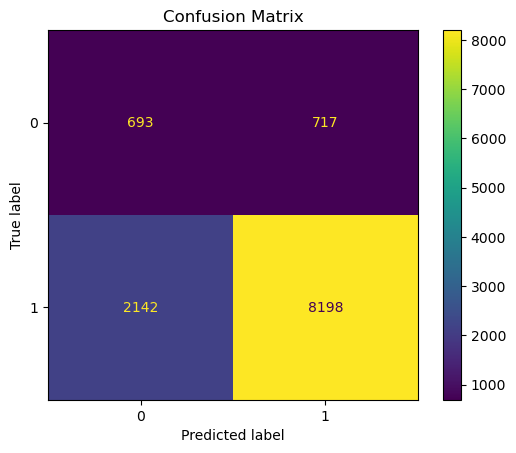

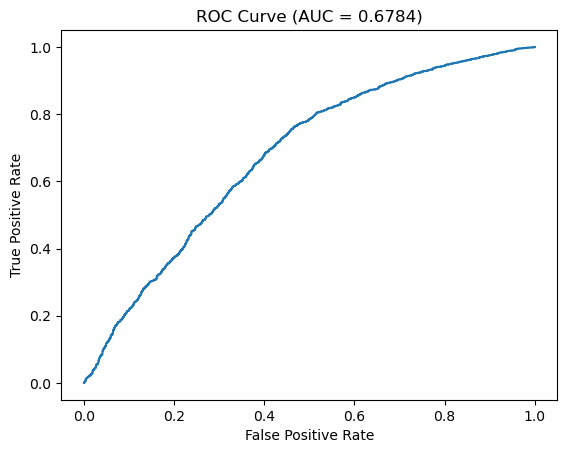

In [18]:
# ============================================================
# 1️⃣6️⃣ EVALUATION (FULL)
# ============================================================

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    roc_curve,
    auc
)

model.eval()

X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

with torch.no_grad():
    probs = torch.sigmoid(model(X_test_t)).cpu().numpy()

# Threshold tuning (you used 0.4)
preds = (probs > 0.4).astype(int)

# =========================
# ✅ Accuracy
# =========================
acc = accuracy_score(y_test, preds)
print(f"\n✅ Accuracy: {acc:.4f}")

# =========================
# 📊 Classification Report
# =========================
print("\n📊 Classification Report:\n")
print(classification_report(y_test, preds))

# =========================
# 🔥 Confusion Matrix
# =========================
cm = confusion_matrix(y_test, preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

# =========================
# 📈 ROC Curve
# =========================
fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {roc_auc:.4f})")
plt.show()

# 2

In [76]:
# ============================================================
# 🔥 PRODUCTION PIPELINE: GCN + ATTENTION + XGBOOST + BUSINESS FEATURES
# ============================================================

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import ast
import itertools

from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

from torch_geometric.nn import GCNConv
from torch_geometric.utils import negative_sampling

from xgboost import XGBClassifier

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================================
# 0️⃣ BUSINESS FEATURES (🔥 NEW ADDITION)
# ============================================================

df['High_Payment_Flag'] = (df['Payments'] > 12000).astype(int)
df['High_LOS_Flag'] = (df['LOS'] > 10).astype(int)
df['MCC_Flag'] = df['A_DX_MCC_Set'].apply(lambda x: 1 if len(x) > 0 else 0)

# ============================================================
# 1️⃣ LOAD ICD EMBEDDINGS
# ============================================================

pretrained_embedding = pd.read_json(
    "hf://datasets/attuneengineering/ICD_10_Embedding_Collection/ICD_10_embedding_collection.json"
)

def safe_to_dict(x):
    if isinstance(x, dict): return x
    if isinstance(x, str):
        try: return ast.literal_eval(x)
        except: return {}
    return {}

def safe_embedding(emb, dim=512):
    if isinstance(emb, list):
        arr = np.array(emb, dtype=np.float32)
        if arr.shape[0] == dim:
            return arr
    return np.zeros(dim, dtype=np.float32)

def norm_icd(x):
    return str(x).upper().replace('.', '').strip()

pretrained_embedding['metadata'] = pretrained_embedding['metadata'].apply(safe_to_dict)
pretrained_embedding = pretrained_embedding.reset_index(drop=True)

meta_df = pd.json_normalize(pretrained_embedding.pop('metadata'))
pretrained_embedding = pd.concat([pretrained_embedding, meta_df], axis=1)

pretrained_embedding['id'] = pretrained_embedding['id'].astype(str).apply(norm_icd)
pretrained_embedding['embedding'] = pretrained_embedding['embedding'].apply(safe_embedding)

icd_embedding_map = dict(zip(pretrained_embedding['id'], pretrained_embedding['embedding']))

# ============================================================
# 2️⃣ HELPERS
# ============================================================

def ensure_list(x):
    if isinstance(x, list): return x
    if pd.isna(x) or x == "": return []
    if isinstance(x, str) and x.startswith('['):
        try: return ast.literal_eval(x)
        except: return []
    if isinstance(x, str):
        return [i.strip() for i in x.split(',') if i.strip()]
    return []

def get_all_icds(row):
    return list(set(
        row['A_DX_MCC_Set'] +
        row['A_DX_CC_Set'] +
        row['A_DX_General_Set']
    ))

# ============================================================
# 3️⃣ TRAIN TEST SPLIT
# ============================================================

train_df, test_df = train_test_split(
    df, test_size=0.2, stratify=df['Status_binary'], random_state=42
)

icd_cols = ['A_DX_MCC_Set','A_DX_CC_Set','A_DX_General_Set']

for col in icd_cols:
    train_df[col] = train_df[col].apply(ensure_list)
    train_df[col] = train_df[col].apply(lambda lst: [norm_icd(i) for i in lst])

# ============================================================
# 4️⃣ BUILD GRAPH
# ============================================================

cooc = defaultdict(int)

for _, row in train_df.iterrows():
    icds = get_all_icds(row)
    for i, j in itertools.combinations(icds, 2):
        cooc[(i, j)] += 1
        cooc[(j, i)] += 1

nodes = list(set([i for pair in cooc for i in pair]))
node2idx = {n:i for i,n in enumerate(nodes)}

edge_index = []

for (i, j), w in cooc.items():
    if w >= 2:
        edge_index.append([node2idx[i], node2idx[j]])

edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous().to(device)

# ============================================================
# 5️⃣ NODE FEATURES
# ============================================================

def get_embedding(icd):
    if icd in icd_embedding_map:
        return icd_embedding_map[icd]
    return np.random.normal(0, 0.1, 512)

X = np.array([get_embedding(n) for n in nodes])
X = torch.tensor(X, dtype=torch.float).to(device)

# ============================================================
# 6️⃣ GCN MODEL
# ============================================================

class GCN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(512, 128)
        self.conv2 = GCNConv(128, 128)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x

model_gnn = GCN().to(device)
optimizer = torch.optim.Adam(model_gnn.parameters(), lr=1e-3)

# ============================================================
# 7️⃣ TRAIN GNN
# ============================================================

for epoch in range(15):
    model_gnn.train()
    optimizer.zero_grad()

    z = model_gnn(X, edge_index)

    src, dst = edge_index
    pos_score = (z[src] * z[dst]).sum(dim=1)

    neg_edge_index = negative_sampling(edge_index, num_nodes=z.size(0))
    n_src, n_dst = neg_edge_index
    neg_score = (z[n_src] * z[n_dst]).sum(dim=1)

    loss = -torch.log(torch.sigmoid(pos_score)).mean() \
           -torch.log(1 - torch.sigmoid(neg_score)).mean()

    loss.backward()
    optimizer.step()

    print(f"GNN Epoch {epoch+1}, Loss: {loss.item():.4f}")

# ============================================================
# 8️⃣ FINAL NODE EMBEDDINGS
# ============================================================

model_gnn.eval()
with torch.no_grad():
    final_emb = model_gnn(X, edge_index).cpu().numpy()

gnn_embedding_map = {nodes[i]: final_emb[i] for i in range(len(nodes))}

# ============================================================
# 9️⃣ ATTENTION POOLING
# ============================================================

class AttentionPool(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.attn = nn.Linear(dim, 1)

    def forward(self, embeddings):
        embeddings = torch.tensor(embeddings, dtype=torch.float32)
        scores = self.attn(embeddings)
        weights = torch.softmax(scores, dim=0)
        pooled = (weights * embeddings).sum(dim=0)
        return pooled.detach().numpy()

attn_pool = AttentionPool(128)

def get_claim_embedding(row):
    icds = get_all_icds(row)
    embs = [gnn_embedding_map[i] for i in icds if i in gnn_embedding_map]

    if len(embs) == 0:
        return np.zeros(128)

    return attn_pool(embs)

train_df['gnn_emb'] = train_df.apply(get_claim_embedding, axis=1)

# ============================================================
# 🔟 FINAL FEATURE MATRIX (🔥 UPDATED)
# ============================================================

tabular_cols = [
    'Payments','AGE','LOS',
    'A_DX_MCC_Count','A_DX_CC_Count','A_DX_General_Count',
    'HighPay_MCC','HighLOS_MCC','HighPay_HighLOS'
    #'High_Payment_Flag','High_LOS_Flag','MCC_Flag'   # 🔥 NEW FEATURES
]

X_tab = train_df[tabular_cols].values
X_gnn = np.vstack(train_df['gnn_emb'].values)

X_final = np.hstack([X_tab, X_gnn])
y = train_df['Status_binary'].values

# ============================================================
# 1️⃣1️⃣ SPLIT + SCALE
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ============================================================
# 1️⃣2️⃣ XGBOOST MODEL
# ============================================================

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train, y_train)

# ============================================================
# 1️⃣3️⃣ EVALUATION
# ============================================================

probs = model.predict_proba(X_test)[:,1]
preds = (probs > 0.5).astype(int)

print("\n🔥 FINAL MODEL RESULTS\n")
print(classification_report(y_test, preds))

GNN Epoch 1, Loss: 1.3668
GNN Epoch 2, Loss: 1.3377
GNN Epoch 3, Loss: 1.2981
GNN Epoch 4, Loss: 1.2505
GNN Epoch 5, Loss: 1.2008
GNN Epoch 6, Loss: 1.1612
GNN Epoch 7, Loss: 1.1426
GNN Epoch 8, Loss: 1.1418
GNN Epoch 9, Loss: 1.1351
GNN Epoch 10, Loss: 1.1141
GNN Epoch 11, Loss: 1.0900
GNN Epoch 12, Loss: 1.0735
GNN Epoch 13, Loss: 1.0637
GNN Epoch 14, Loss: 1.0510
GNN Epoch 15, Loss: 1.0321

🔥 FINAL MODEL RESULTS

              precision    recall  f1-score   support

           0       0.18      0.58      0.28      1410
           1       0.92      0.65      0.76     10340

    accuracy                           0.64     11750
   macro avg       0.55      0.61      0.52     11750
weighted avg       0.83      0.64      0.70     11750




🔥 Results at Threshold = 0.5

              precision    recall  f1-score   support

           0       0.18      0.58      0.28      1410
           1       0.92      0.65      0.76     10340

    accuracy                           0.64     11750
   macro avg       0.55      0.61      0.52     11750
weighted avg       0.83      0.64      0.70     11750


Confusion Matrix:
 [[ 814  596]
 [3603 6737]]


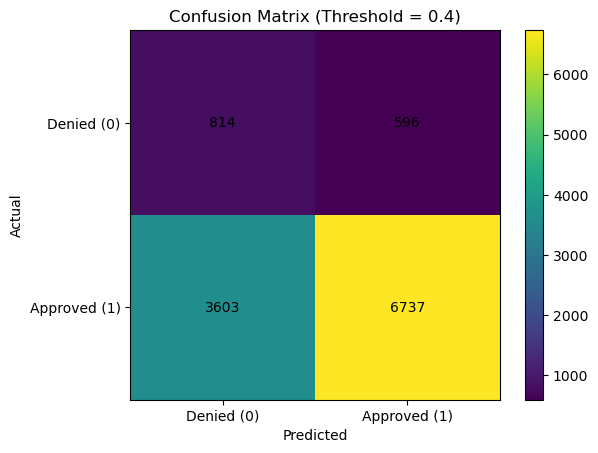

In [77]:
# ============================================================
# 🔥 FIXED THRESHOLD = 0.4
# ============================================================

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Probabilities
probs = model.predict_proba(X_test)[:,1]

# Apply threshold
threshold = 0.5
preds = (probs > threshold).astype(int)

# Classification report
print(f"\n🔥 Results at Threshold = {threshold}\n")
print(classification_report(y_test, preds))


# ============================================================
# 🔥 CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, preds)

print("\nConfusion Matrix:\n", cm)


# ============================================================
# 🔥 CONFUSION MATRIX PLOT
# ============================================================

plt.figure()

plt.imshow(cm)

plt.title("Confusion Matrix (Threshold = 0.4)")
plt.colorbar()

classes = ['Denied (0)', 'Approved (1)']
tick_marks = np.arange(len(classes))

plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

# Add numbers inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.show()

In [78]:
# ============================================================
# 🔥 FEATURE IMPORTANCE (BASIC)
# ============================================================

import pandas as pd

# Get feature names (IMPORTANT: match your feature order)
feature_names = tabular_cols + [f'gnn_{i}' for i in range(X_gnn.shape[1])]

# Get importance
importance = model.feature_importances_

# Create dataframe
feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
}).sort_values(by='importance', ascending=False)

# Show top 20
print("\n🔥 TOP FEATURES\n")
print(feat_imp_df.head(20))


🔥 TOP FEATURES

            feature  importance
7       HighLOS_MCC    0.022491
0          Payments    0.013095
2               LOS    0.012602
86           gnn_77    0.012189
6       HighPay_MCC    0.011220
3    A_DX_MCC_Count    0.010651
134         gnn_125    0.010412
44           gnn_35    0.009912
17            gnn_8    0.009819
77           gnn_68    0.009791
118         gnn_109    0.009622
92           gnn_83    0.009297
98           gnn_89    0.009133
126         gnn_117    0.008941
48           gnn_39    0.008889
19           gnn_10    0.008742
79           gnn_70    0.008616
33           gnn_24    0.008587
61           gnn_52    0.008547
73           gnn_64    0.008505


In [79]:
feat_imp_df.shape

(137, 2)

# GCN + XGB 

In [66]:
# ============================================================
# 🔥 PRODUCTION PIPELINE: GCN + ATTENTION + XGBOOST + BUSINESS FEATURES
# ============================================================

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import ast
import itertools

from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

from torch_geometric.nn import GCNConv
from torch_geometric.utils import negative_sampling

from xgboost import XGBClassifier

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================================
# 0️⃣ BUSINESS FEATURES (🔥 NEW ADDITION)
# ============================================================

df['High_Payment_Flag'] = (df['Payments'] > 12000).astype(int)
df['High_LOS_Flag'] = (df['LOS'] > 10).astype(int)
df['MCC_Flag'] = df['A_DX_MCC_Set'].apply(lambda x: 1 if len(x) > 0 else 0)

# ============================================================
# 1️⃣ LOAD ICD EMBEDDINGS
# ============================================================

pretrained_embedding = pd.read_json(
    "hf://datasets/attuneengineering/ICD_10_Embedding_Collection/ICD_10_embedding_collection.json"
)

def safe_to_dict(x):
    if isinstance(x, dict): return x
    if isinstance(x, str):
        try: return ast.literal_eval(x)
        except: return {}
    return {}

def safe_embedding(emb, dim=512):
    if isinstance(emb, list):
        arr = np.array(emb, dtype=np.float32)
        if arr.shape[0] == dim:
            return arr
    return np.zeros(dim, dtype=np.float32)

def norm_icd(x):
    return str(x).upper().replace('.', '').strip()

pretrained_embedding['metadata'] = pretrained_embedding['metadata'].apply(safe_to_dict)
pretrained_embedding = pretrained_embedding.reset_index(drop=True)

meta_df = pd.json_normalize(pretrained_embedding.pop('metadata'))
pretrained_embedding = pd.concat([pretrained_embedding, meta_df], axis=1)

pretrained_embedding['id'] = pretrained_embedding['id'].astype(str).apply(norm_icd)
pretrained_embedding['embedding'] = pretrained_embedding['embedding'].apply(safe_embedding)

icd_embedding_map = dict(zip(pretrained_embedding['id'], pretrained_embedding['embedding']))

# ============================================================
# 2️⃣ HELPERS
# ============================================================

def ensure_list(x):
    if isinstance(x, list): return x
    if pd.isna(x) or x == "": return []
    if isinstance(x, str) and x.startswith('['):
        try: return ast.literal_eval(x)
        except: return []
    if isinstance(x, str):
        return [i.strip() for i in x.split(',') if i.strip()]
    return []

def get_all_icds(row):
    return list(set(
        row['A_DX_MCC_Set'] +
        row['A_DX_CC_Set'] +
        row['A_DX_General_Set']
    ))

# ============================================================
# 3️⃣ TRAIN TEST SPLIT
# ============================================================

train_df, test_df = train_test_split(
    df, test_size=0.2, stratify=df['Status_binary'], random_state=42
)

icd_cols = ['A_DX_MCC_Set','A_DX_CC_Set','A_DX_General_Set']

for col in icd_cols:
    train_df[col] = train_df[col].apply(ensure_list)
    train_df[col] = train_df[col].apply(lambda lst: [norm_icd(i) for i in lst])

# ============================================================
# 4️⃣ BUILD GRAPH
# ============================================================

cooc = defaultdict(int)

for _, row in train_df.iterrows():
    icds = get_all_icds(row)
    for i, j in itertools.combinations(icds, 2):
        cooc[(i, j)] += 1
        cooc[(j, i)] += 1

nodes = list(set([i for pair in cooc for i in pair]))
node2idx = {n:i for i,n in enumerate(nodes)}

edge_index = []

for (i, j), w in cooc.items():
    if w >= 2:
        edge_index.append([node2idx[i], node2idx[j]])

edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous().to(device)

# ============================================================
# 5️⃣ NODE FEATURES
# ============================================================

def get_embedding(icd):
    if icd in icd_embedding_map:
        return icd_embedding_map[icd]
    return np.random.normal(0, 0.1, 512)

X = np.array([get_embedding(n) for n in nodes])
X = torch.tensor(X, dtype=torch.float).to(device)

# ============================================================
# 6️⃣ GCN MODEL
# ============================================================

class GCN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(512, 128)
        self.conv2 = GCNConv(128, 128)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x

model_gnn = GCN().to(device)
optimizer = torch.optim.Adam(model_gnn.parameters(), lr=1e-3)

# ============================================================
# 7️⃣ TRAIN GNN
# ============================================================

for epoch in range(15):
    model_gnn.train()
    optimizer.zero_grad()

    z = model_gnn(X, edge_index)

    src, dst = edge_index
    pos_score = (z[src] * z[dst]).sum(dim=1)

    neg_edge_index = negative_sampling(edge_index, num_nodes=z.size(0))
    n_src, n_dst = neg_edge_index
    neg_score = (z[n_src] * z[n_dst]).sum(dim=1)

    loss = -torch.log(torch.sigmoid(pos_score)).mean() \
           -torch.log(1 - torch.sigmoid(neg_score)).mean()

    loss.backward()
    optimizer.step()

    print(f"GNN Epoch {epoch+1}, Loss: {loss.item():.4f}")

# ============================================================
# 8️⃣ FINAL NODE EMBEDDINGS
# ============================================================

model_gnn.eval()
with torch.no_grad():
    final_emb = model_gnn(X, edge_index).cpu().numpy()

gnn_embedding_map = {nodes[i]: final_emb[i] for i in range(len(nodes))}

# ============================================================
# 9️⃣ ATTENTION POOLING
# ============================================================

class AttentionPool(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.attn = nn.Linear(dim, 1)

    def forward(self, embeddings):
        embeddings = torch.tensor(embeddings, dtype=torch.float32)
        scores = self.attn(embeddings)
        weights = torch.softmax(scores, dim=0)
        pooled = (weights * embeddings).sum(dim=0)
        return pooled.detach().numpy()

attn_pool = AttentionPool(128)

def get_claim_embedding(row):
    icds = get_all_icds(row)
    embs = [gnn_embedding_map[i] for i in icds if i in gnn_embedding_map]

    if len(embs) == 0:
        return np.zeros(128)

    return attn_pool(embs)

train_df['gnn_emb'] = train_df.apply(get_claim_embedding, axis=1)

# ============================================================
# 🔟 FINAL FEATURE MATRIX (🔥 UPDATED)
# ============================================================

tabular_cols = [
    'Payments','AGE','LOS',
    'A_DX_MCC_Count','A_DX_CC_Count','A_DX_General_Count',
    'High_Payment_Flag','High_LOS_Flag','MCC_Flag'   # 🔥 NEW FEATURES
]

X_tab = train_df[tabular_cols].values
X_gnn = np.vstack(train_df['gnn_emb'].values)

X_final = np.hstack([X_tab, X_gnn])
y = train_df['Status_binary'].values

# ============================================================
# 1️⃣1️⃣ SPLIT + SCALE
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ============================================================
# 1️⃣2️⃣ XGBOOST MODEL
# ============================================================

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train, y_train)

# ============================================================
# 1️⃣3️⃣ EVALUATION
# ============================================================

probs = model.predict_proba(X_test)[:,1]
preds = (probs > 0.5).astype(int)

print("\n🔥 FINAL MODEL RESULTS\n")
print(classification_report(y_test, preds))

GNN Epoch 1, Loss: 1.3621
GNN Epoch 2, Loss: 1.3305
GNN Epoch 3, Loss: 1.2880
GNN Epoch 4, Loss: 1.2399
GNN Epoch 5, Loss: 1.1944
GNN Epoch 6, Loss: 1.1639
GNN Epoch 7, Loss: 1.1561
GNN Epoch 8, Loss: 1.1566
GNN Epoch 9, Loss: 1.1451
GNN Epoch 10, Loss: 1.1222
GNN Epoch 11, Loss: 1.1001
GNN Epoch 12, Loss: 1.0864
GNN Epoch 13, Loss: 1.0754
GNN Epoch 14, Loss: 1.0614
GNN Epoch 15, Loss: 1.0427

🔥 FINAL MODEL RESULTS

              precision    recall  f1-score   support

           0       0.18      0.58      0.28      1410
           1       0.92      0.65      0.76     10340

    accuracy                           0.64     11750
   macro avg       0.55      0.61      0.52     11750
weighted avg       0.83      0.64      0.70     11750



In [67]:
# ============================================================
# 1️⃣3️⃣ EVALUATION
# ============================================================

probs = model.predict_proba(X_test)[:,1]
preds = (probs > 0.4).astype(int)

print("\n🔥 FINAL MODEL RESULTS\n")
print(classification_report(y_test, preds))


🔥 FINAL MODEL RESULTS

              precision    recall  f1-score   support

           0       0.26      0.22      0.24      1410
           1       0.90      0.91      0.90     10340

    accuracy                           0.83     11750
   macro avg       0.58      0.57      0.57     11750
weighted avg       0.82      0.83      0.82     11750



# GCN + XGBOOST

In [39]:
# ============================================================
# 🔥 PRODUCTION PIPELINE: GCN + ATTENTION POOLING + XGBOOST
# ============================================================

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import ast
import itertools

from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

from torch_geometric.nn import GCNConv
from torch_geometric.utils import negative_sampling

from xgboost import XGBClassifier

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================================
# 1️⃣ LOAD ICD EMBEDDINGS
# ============================================================

pretrained_embedding = pd.read_json(
    "hf://datasets/attuneengineering/ICD_10_Embedding_Collection/ICD_10_embedding_collection.json"
)

def safe_to_dict(x):
    if isinstance(x, dict): return x
    if isinstance(x, str):
        try: return ast.literal_eval(x)
        except: return {}
    return {}

def safe_embedding(emb, dim=512):
    if isinstance(emb, list):
        arr = np.array(emb, dtype=np.float32)
        if arr.shape[0] == dim:
            return arr
    return np.zeros(dim, dtype=np.float32)

def norm_icd(x):
    return str(x).upper().replace('.', '').strip()

pretrained_embedding['metadata'] = pretrained_embedding['metadata'].apply(safe_to_dict)
pretrained_embedding = pretrained_embedding.reset_index(drop=True)

meta_df = pd.json_normalize(pretrained_embedding.pop('metadata'))
pretrained_embedding = pd.concat([pretrained_embedding, meta_df], axis=1)

pretrained_embedding['id'] = pretrained_embedding['id'].astype(str).apply(norm_icd)
pretrained_embedding['embedding'] = pretrained_embedding['embedding'].apply(safe_embedding)

icd_embedding_map = dict(zip(pretrained_embedding['id'], pretrained_embedding['embedding']))

# ============================================================
# 2️⃣ HELPERS
# ============================================================

def ensure_list(x):
    if isinstance(x, list): return x
    if pd.isna(x) or x == "": return []
    if isinstance(x, str) and x.startswith('['):
        try: return ast.literal_eval(x)
        except: return []
    if isinstance(x, str):
        return [i.strip() for i in x.split(',') if i.strip()]
    return []

def get_all_icds(row):
    return list(set(
        row['A_DX_MCC_Set'] +
        row['A_DX_CC_Set'] +
        row['A_DX_General_Set']
    ))

# ============================================================
# 3️⃣ TRAIN TEST SPLIT
# ============================================================

train_df, test_df = train_test_split(
    df, test_size=0.2, stratify=df['Status_binary'], random_state=42
)

icd_cols = ['A_DX_MCC_Set','A_DX_CC_Set','A_DX_General_Set']

for col in icd_cols:
    train_df[col] = train_df[col].apply(ensure_list)
    train_df[col] = train_df[col].apply(lambda lst: [norm_icd(i) for i in lst])

# ============================================================
# 4️⃣ BUILD GRAPH
# ============================================================

cooc = defaultdict(int)

for _, row in train_df.iterrows():
    icds = get_all_icds(row)
    for i, j in itertools.combinations(icds, 2):
        cooc[(i, j)] += 1
        cooc[(j, i)] += 1

nodes = list(set([i for pair in cooc for i in pair]))
node2idx = {n:i for i,n in enumerate(nodes)}

edge_index = []

for (i, j), w in cooc.items():
    if w >= 2:
        edge_index.append([node2idx[i], node2idx[j]])

edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous().to(device)

# ============================================================
# 5️⃣ NODE FEATURES
# ============================================================

def get_embedding(icd):
    if icd in icd_embedding_map:
        return icd_embedding_map[icd]
    return np.random.normal(0, 0.1, 512)

X = np.array([get_embedding(n) for n in nodes])
X = torch.tensor(X, dtype=torch.float).to(device)

# ============================================================
# 6️⃣ GCN MODEL
# ============================================================

class GCN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(512, 128)
        self.conv2 = GCNConv(128, 128)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x

model_gnn = GCN().to(device)
optimizer = torch.optim.Adam(model_gnn.parameters(), lr=1e-3)

# ============================================================
# 7️⃣ TRAIN GNN
# ============================================================

for epoch in range(15):
    model_gnn.train()
    optimizer.zero_grad()

    z = model_gnn(X, edge_index)

    src, dst = edge_index
    pos_score = (z[src] * z[dst]).sum(dim=1)

    neg_edge_index = negative_sampling(edge_index, num_nodes=z.size(0))
    n_src, n_dst = neg_edge_index
    neg_score = (z[n_src] * z[n_dst]).sum(dim=1)

    loss = -torch.log(torch.sigmoid(pos_score)).mean() \
           -torch.log(1 - torch.sigmoid(neg_score)).mean()

    loss.backward()
    optimizer.step()

    print(f"GNN Epoch {epoch+1}, Loss: {loss.item():.4f}")

# ============================================================
# 8️⃣ FINAL NODE EMBEDDINGS
# ============================================================

model_gnn.eval()
with torch.no_grad():
    final_emb = model_gnn(X, edge_index).cpu().numpy()

gnn_embedding_map = {nodes[i]: final_emb[i] for i in range(len(nodes))}

# ============================================================
# 9️⃣ ATTENTION POOLING (🔥 KEY UPGRADE)
# ============================================================

class AttentionPool(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.attn = nn.Linear(dim, 1)

    def forward(self, embeddings):
        scores = self.attn(torch.tensor(embeddings, dtype=torch.float32))
        weights = torch.softmax(scores, dim=0)
        pooled = (weights * torch.tensor(embeddings)).sum(dim=0)
        return pooled.detach().numpy()

attn_pool = AttentionPool(128)

def get_claim_embedding(row):
    icds = get_all_icds(row)
    embs = [gnn_embedding_map[i] for i in icds if i in gnn_embedding_map]

    if len(embs) == 0:
        return np.zeros(128)

    return attn_pool(embs)

train_df['gnn_emb'] = train_df.apply(get_claim_embedding, axis=1)

# ============================================================
# 🔟 FINAL FEATURE MATRIX
# ============================================================

tabular_cols = ['Payments','AGE','LOS',
                'A_DX_MCC_Count','A_DX_CC_Count','A_DX_General_Count']

X_tab = train_df[tabular_cols].values
X_gnn = np.vstack(train_df['gnn_emb'].values)

X_final = np.hstack([X_tab, X_gnn])
y = train_df['Status_binary'].values

# ============================================================
# 1️⃣1️⃣ SPLIT + SCALE
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ============================================================
# 1️⃣2️⃣ XGBOOST MODEL (🔥 INDUSTRY STANDARD)
# ============================================================

# Handle imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train, y_train)

# ============================================================
# 1️⃣3️⃣ EVALUATION + THRESHOLD TUNING
# ============================================================

probs = model.predict_proba(X_test)[:,1]

print("\n🔥 Threshold tuning:\n")

for t in [0.2, 0.3, 0.4, 0.5]:
    preds = (probs > t).astype(int)
    print(f"\nThreshold = {t}")
    print(classification_report(y_test, preds))

GNN Epoch 1, Loss: 1.3638
GNN Epoch 2, Loss: 1.3326
GNN Epoch 3, Loss: 1.2907
GNN Epoch 4, Loss: 1.2413
GNN Epoch 5, Loss: 1.1925
GNN Epoch 6, Loss: 1.1558
GNN Epoch 7, Loss: 1.1413
GNN Epoch 8, Loss: 1.1426
GNN Epoch 9, Loss: 1.1366
GNN Epoch 10, Loss: 1.1176
GNN Epoch 11, Loss: 1.0943
GNN Epoch 12, Loss: 1.0780
GNN Epoch 13, Loss: 1.0686
GNN Epoch 14, Loss: 1.0577
GNN Epoch 15, Loss: 1.0407


C:\Users\arunkumara\AppData\Local\Temp\8\ipykernel_25120\3240148496.py:195: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  scores = self.attn(torch.tensor(embeddings, dtype=torch.float32))



🔥 Threshold tuning:


Threshold = 0.2
              precision    recall  f1-score   support

           0       0.62      0.01      0.01      1410
           1       0.88      1.00      0.94     10340

    accuracy                           0.88     11750
   macro avg       0.75      0.50      0.47     11750
weighted avg       0.85      0.88      0.83     11750


Threshold = 0.3
              precision    recall  f1-score   support

           0       0.32      0.05      0.09      1410
           1       0.88      0.99      0.93     10340

    accuracy                           0.87     11750
   macro avg       0.60      0.52      0.51     11750
weighted avg       0.82      0.87      0.83     11750


Threshold = 0.4
              precision    recall  f1-score   support

           0       0.25      0.23      0.24      1410
           1       0.90      0.91      0.90     10340

    accuracy                           0.83     11750
   macro avg       0.57      0.57      0.57     11750
w


🔥 Results at Threshold = 0.5

              precision    recall  f1-score   support

           0       0.19      0.52      0.28      1410
           1       0.92      0.71      0.80     10340

    accuracy                           0.68     11750
   macro avg       0.56      0.61      0.54     11750
weighted avg       0.83      0.68      0.74     11750


Confusion Matrix:
 [[ 737  673]
 [3050 7290]]


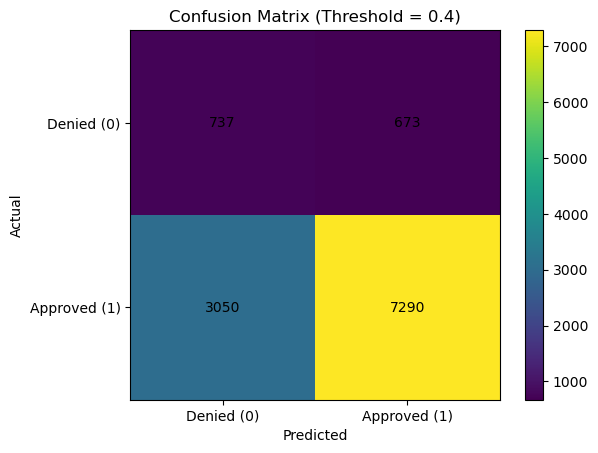

In [50]:
# ============================================================
# 🔥 FIXED THRESHOLD = 0.4
# ============================================================

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Probabilities
probs = model.predict_proba(X_test)[:,1]

# Apply threshold
threshold = 0.5
preds = (probs > threshold).astype(int)

# Classification report
print(f"\n🔥 Results at Threshold = {threshold}\n")
print(classification_report(y_test, preds))


# ============================================================
# 🔥 CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, preds)

print("\nConfusion Matrix:\n", cm)


# ============================================================
# 🔥 CONFUSION MATRIX PLOT
# ============================================================

plt.figure()

plt.imshow(cm)

plt.title("Confusion Matrix (Threshold = 0.4)")
plt.colorbar()

classes = ['Denied (0)', 'Approved (1)']
tick_marks = np.arange(len(classes))

plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

# Add numbers inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.show()

# GCN - Updated1

In [30]:
# ============================================================
# 🔥 FULL CLAIM PREDICTION PIPELINE (IMBALANCE FIXED)
# ============================================================

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import ast
import itertools

from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

from torch_geometric.nn import GCNConv
from torch_geometric.utils import negative_sampling

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================================
# 1️⃣ LOAD ICD EMBEDDINGS
# ============================================================

pretrained_embedding = pd.read_json(
    "hf://datasets/attuneengineering/ICD_10_Embedding_Collection/ICD_10_embedding_collection.json"
)

def safe_to_dict(x):
    if isinstance(x, dict): return x
    if isinstance(x, str):
        try: return ast.literal_eval(x)
        except: return {}
    return {}

def safe_embedding(emb, dim=512):
    if isinstance(emb, list):
        arr = np.array(emb, dtype=np.float32)
        if arr.shape[0] == dim:
            return arr
    return np.zeros(dim, dtype=np.float32)

def norm_icd(x):
    return str(x).upper().replace('.', '').strip()

pretrained_embedding['metadata'] = pretrained_embedding['metadata'].apply(safe_to_dict)
pretrained_embedding = pretrained_embedding.reset_index(drop=True)

meta_df = pd.json_normalize(pretrained_embedding.pop('metadata'))
pretrained_embedding = pd.concat([pretrained_embedding, meta_df], axis=1)

pretrained_embedding['id'] = pretrained_embedding['id'].astype(str).apply(norm_icd)
pretrained_embedding['embedding'] = pretrained_embedding['embedding'].apply(safe_embedding)

icd_embedding_map = dict(zip(pretrained_embedding['id'], pretrained_embedding['embedding']))

# ============================================================
# 2️⃣ HELPERS
# ============================================================

def ensure_list(x):
    if isinstance(x, list): return x
    if pd.isna(x) or x == "": return []
    if isinstance(x, str) and x.startswith('['):
        try: return ast.literal_eval(x)
        except: return []
    if isinstance(x, str):
        return [i.strip() for i in x.split(',') if i.strip()]
    return []

def get_all_icds(row):
    return list(set(
        row['A_DX_MCC_Set'] +
        row['A_DX_CC_Set'] +
        row['A_DX_General_Set']
    ))

# ============================================================
# 3️⃣ TRAIN TEST SPLIT
# ============================================================

train_df, test_df = train_test_split(
    df, test_size=0.2, stratify=df['Status_binary'], random_state=42
)

icd_cols = ['A_DX_MCC_Set','A_DX_CC_Set','A_DX_General_Set']

for col in icd_cols:
    train_df[col] = train_df[col].apply(ensure_list)
    train_df[col] = train_df[col].apply(lambda lst: [norm_icd(i) for i in lst])

# ============================================================
# 4️⃣ BUILD GRAPH
# ============================================================

cooc = defaultdict(int)

for _, row in train_df.iterrows():
    icds = get_all_icds(row)
    for i, j in itertools.combinations(icds, 2):
        cooc[(i, j)] += 1
        cooc[(j, i)] += 1

nodes = list(set([i for pair in cooc for i in pair]))
node2idx = {n:i for i,n in enumerate(nodes)}

edge_index = []

for (i, j), w in cooc.items():
    if w >= 2:
        edge_index.append([node2idx[i], node2idx[j]])

edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous().to(device)

# ============================================================
# 5️⃣ NODE FEATURES
# ============================================================

def get_embedding(icd):
    if icd in icd_embedding_map:
        return icd_embedding_map[icd]
    return np.random.normal(0, 0.1, 512)

X = np.array([get_embedding(n) for n in nodes])
X = torch.tensor(X, dtype=torch.float).to(device)

# ============================================================
# 6️⃣ GCN MODEL
# ============================================================

class GCN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(512, 128)
        self.conv2 = GCNConv(128, 128)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x

model_gnn = GCN().to(device)
optimizer = torch.optim.Adam(model_gnn.parameters(), lr=1e-3)

# ============================================================
# 7️⃣ TRAIN GNN
# ============================================================

for epoch in range(15):
    model_gnn.train()
    optimizer.zero_grad()

    z = model_gnn(X, edge_index)

    src, dst = edge_index
    pos_score = (z[src] * z[dst]).sum(dim=1)

    neg_edge_index = negative_sampling(edge_index, num_nodes=z.size(0))
    n_src, n_dst = neg_edge_index
    neg_score = (z[n_src] * z[n_dst]).sum(dim=1)

    loss = -torch.log(torch.sigmoid(pos_score)).mean() \
           -torch.log(1 - torch.sigmoid(neg_score)).mean()

    loss.backward()
    optimizer.step()

    print(f"GNN Epoch {epoch+1}, Loss: {loss.item():.4f}")

# ============================================================
# 8️⃣ FINAL NODE EMBEDDINGS
# ============================================================

model_gnn.eval()
with torch.no_grad():
    final_emb = model_gnn(X, edge_index).cpu().numpy()

gnn_embedding_map = {nodes[i]: final_emb[i] for i in range(len(nodes))}

# ============================================================
# 9️⃣ CLAIM EMBEDDINGS (🔥 MAX POOLING)
# ============================================================

def get_claim_embedding(row):
    icds = get_all_icds(row)
    embs = [gnn_embedding_map[i] for i in icds if i in gnn_embedding_map]

    if len(embs) == 0:
        return np.zeros(128)

    return np.max(embs, axis=0)  # 🔥 IMPORTANT CHANGE

train_df['gnn_emb'] = train_df.apply(get_claim_embedding, axis=1)

# ============================================================
# 🔟 FINAL FEATURES
# ============================================================

tabular_cols = ['Payments','AGE','LOS',
                'A_DX_MCC_Count','A_DX_CC_Count','A_DX_General_Count']

X_tab = train_df[tabular_cols].values
X_gnn = np.vstack(train_df['gnn_emb'].values)

X_final = np.hstack([X_tab, X_gnn])
y = train_df['Status_binary'].values

# ============================================================
# 1️⃣1️⃣ SPLIT + SCALE
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ============================================================
# 1️⃣2️⃣ FOCAL LOSS (FIXED)
# ============================================================

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.15, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        pt = torch.exp(-bce)

        alpha_t = targets * (1 - self.alpha) + (1 - targets) * self.alpha

        loss = alpha_t * (1 - pt) ** self.gamma * bce
        return loss.mean()

# ============================================================
# 1️⃣3️⃣ CLASSIFIER
# ============================================================

class ClaimModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze()

# ============================================================
# 1️⃣4️⃣ TRAIN
# ============================================================

X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)

model = ClaimModel(X_train.shape[1]).to(device)

criterion = FocalLoss(alpha=0.15, gamma=2)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(20):
    model.train()
    optimizer.zero_grad()

    logits = model(X_train_t)
    loss = criterion(logits, y_train_t)

    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

# ============================================================
# 1️⃣5️⃣ EVALUATION + THRESHOLD TUNING
# ============================================================

model.eval()

X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

with torch.no_grad():
    probs = torch.sigmoid(model(X_test_t)).cpu().numpy()

print("\n🔥 Threshold tuning results:\n")

for t in [0.2, 0.3, 0.4, 0.5]:
    preds = (probs > t).astype(int)
    print(f"\nThreshold = {t}")
    print(classification_report(y_test, preds))

GNN Epoch 1, Loss: 1.3655
GNN Epoch 2, Loss: 1.3372
GNN Epoch 3, Loss: 1.2990
GNN Epoch 4, Loss: 1.2532
GNN Epoch 5, Loss: 1.2059
GNN Epoch 6, Loss: 1.1675
GNN Epoch 7, Loss: 1.1483
GNN Epoch 8, Loss: 1.1467
GNN Epoch 9, Loss: 1.1420
GNN Epoch 10, Loss: 1.1255
GNN Epoch 11, Loss: 1.1031
GNN Epoch 12, Loss: 1.0852
GNN Epoch 13, Loss: 1.0739
GNN Epoch 14, Loss: 1.0619
GNN Epoch 15, Loss: 1.0449
Epoch 1, Loss: 0.1669
Epoch 2, Loss: 0.1394
Epoch 3, Loss: 0.1183
Epoch 4, Loss: 0.1018
Epoch 5, Loss: 0.0883
Epoch 6, Loss: 0.0771
Epoch 7, Loss: 0.0676
Epoch 8, Loss: 0.0597
Epoch 9, Loss: 0.0529
Epoch 10, Loss: 0.0474
Epoch 11, Loss: 0.0432
Epoch 12, Loss: 0.0399
Epoch 13, Loss: 0.0378
Epoch 14, Loss: 0.0364
Epoch 15, Loss: 0.0359
Epoch 16, Loss: 0.0357
Epoch 17, Loss: 0.0361
Epoch 18, Loss: 0.0365
Epoch 19, Loss: 0.0372
Epoch 20, Loss: 0.0377

🔥 Threshold tuning results:


Threshold = 0.2
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      14

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\Lib\site-packag

In [35]:
model.eval()

X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

with torch.no_grad():
    probs = torch.sigmoid(model(X_test_t)).cpu().numpy()

print("\n🔥 Threshold tuning results:\n")

for t in [0.02, 0.03, 0.4, 0.5]:
    preds = (probs > t).astype(int)
    print(f"\nThreshold = {t}")
    print(classification_report(y_test, preds))


🔥 Threshold tuning results:


Threshold = 0.02
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1410
           1       0.88      1.00      0.94     10340

    accuracy                           0.88     11750
   macro avg       0.44      0.50      0.47     11750
weighted avg       0.77      0.88      0.82     11750


Threshold = 0.03
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1410
           1       0.88      1.00      0.94     10340

    accuracy                           0.88     11750
   macro avg       0.44      0.50      0.47     11750
weighted avg       0.77      0.88      0.82     11750


Threshold = 0.4
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1410
           1       0.88      1.00      0.94     10340

    accuracy                           0.88     11750
   macro avg       0.44      0.50      0.47  

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\Lib\site-packag

# Grapg Sage

In [11]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import ast
import itertools

from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv
from torch_geometric.utils import negative_sampling

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [12]:
pretrained_embedding = pd.read_json(
    "hf://datasets/attuneengineering/ICD_10_Embedding_Collection/ICD_10_embedding_collection.json"
)

def safe_to_dict(x):
    if isinstance(x, dict): return x
    if isinstance(x, str):
        try: return ast.literal_eval(x)
        except: return {}
    return {}

def safe_embedding(emb, dim=512):
    if isinstance(emb, list):
        arr = np.array(emb, dtype=np.float32)
        if arr.shape[0] == dim:
            return arr
    return np.zeros(dim, dtype=np.float32)

def norm_icd(x):
    return str(x).upper().replace('.', '').strip()

pretrained_embedding['metadata'] = pretrained_embedding['metadata'].apply(safe_to_dict)
pretrained_embedding = pretrained_embedding.reset_index(drop=True)

meta_df = pd.json_normalize(pretrained_embedding.pop('metadata'))
pretrained_embedding = pd.concat([pretrained_embedding, meta_df], axis=1)

pretrained_embedding['id'] = pretrained_embedding['id'].astype(str).apply(norm_icd)
pretrained_embedding['embedding'] = pretrained_embedding['embedding'].apply(safe_embedding)

icd_embedding_map = dict(zip(pretrained_embedding['id'], pretrained_embedding['embedding']))

In [13]:
def ensure_list(x):
    if isinstance(x, list):
        return x
    if pd.isna(x) or x == "":
        return []
    if isinstance(x, str) and x.startswith('['):
        try:
            return ast.literal_eval(x)
        except:
            return []
    if isinstance(x, str):
        return [i.strip() for i in x.split(',') if i.strip() != ""]
    return []

def get_all_icds(row):
    return list(set(
        row['A_DX_MCC_Set'] +
        row['A_DX_CC_Set'] +
        row['A_DX_General_Set']
    ))

In [14]:
train_df, test_df = train_test_split(
    df, test_size=0.2, stratify=df['Status_binary'], random_state=42
)

icd_cols = ['A_DX_MCC_Set','A_DX_CC_Set','A_DX_General_Set']

for col in icd_cols:
    train_df[col] = train_df[col].apply(ensure_list)
    train_df[col] = train_df[col].apply(lambda lst: [norm_icd(i) for i in lst])

In [15]:
cooc = defaultdict(int)

for _, row in train_df.iterrows():
    icds = get_all_icds(row)
    for i, j in itertools.combinations(icds, 2):
        cooc[(i, j)] += 1
        cooc[(j, i)] += 1

def get_parent(icd):
    return icd[:3]

hierarchy_edges = []
all_icds = set()

for _, row in train_df.iterrows():
    all_icds.update(get_all_icds(row))

for icd in all_icds:
    parent = get_parent(icd)
    hierarchy_edges.append((icd, parent))
    hierarchy_edges.append((parent, icd))

In [16]:
nodes = list(set([i for pair in cooc for i in pair]))
node2idx = {n:i for i,n in enumerate(nodes)}

edge_index = []
edge_weight = []

# Co-occurrence edges
for (i, j), w in cooc.items():
    if w >= 2:
        edge_index.append([node2idx[i], node2idx[j]])
        edge_weight.append(w)

# Hierarchy edges
for i, j in hierarchy_edges:
    if i in node2idx and j in node2idx:
        edge_index.append([node2idx[i], node2idx[j]])
        edge_weight.append(1)

edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous().to(device)
edge_weight = torch.tensor(edge_weight, dtype=torch.float).to(device)

In [17]:
def get_embedding(icd):
    if icd in icd_embedding_map:
        return icd_embedding_map[icd]
    return np.random.normal(0, 0.1, 512)

X = np.array([get_embedding(n) for n in nodes])
X = torch.tensor(X, dtype=torch.float).to(device)

In [18]:
class GraphSAGE(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, 128)
        self.conv2 = SAGEConv(128, 128)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x

In [19]:
def graph_smote(z, minority_idx, num_samples=1000):
    synth = []
    for _ in range(num_samples):
        i, j = np.random.choice(minority_idx, 2)
        lam = np.random.rand()
        new_node = lam * z[i] + (1 - lam) * z[j]
        synth.append(new_node)
    return torch.stack(synth)

In [20]:
model_gnn = GraphSAGE(512).to(device)
optimizer = torch.optim.Adam(model_gnn.parameters(), lr=1e-3)

for epoch in range(20):
    model_gnn.train()
    optimizer.zero_grad()

    z = model_gnn(X, edge_index)

    # Positive edges
    src, dst = edge_index
    pos_score = (z[src] * z[dst]).sum(dim=1)

    # Negative edges
    neg_edge_index = negative_sampling(edge_index, num_nodes=z.size(0))
    n_src, n_dst = neg_edge_index
    neg_score = (z[n_src] * z[n_dst]).sum(dim=1)

    loss = -torch.log(torch.sigmoid(pos_score)).mean() \
           -torch.log(1 - torch.sigmoid(neg_score)).mean()

    loss.backward()
    optimizer.step()

    print(f"GNN Epoch {epoch+1}, Loss: {loss.item():.4f}")

GNN Epoch 1, Loss: 1.4113
GNN Epoch 2, Loss: 1.3894
GNN Epoch 3, Loss: 1.3645
GNN Epoch 4, Loss: 1.3340
GNN Epoch 5, Loss: 1.3021
GNN Epoch 6, Loss: 1.2759
GNN Epoch 7, Loss: 1.2451
GNN Epoch 8, Loss: 1.2095
GNN Epoch 9, Loss: 1.1769
GNN Epoch 10, Loss: 1.1452
GNN Epoch 11, Loss: 1.1109
GNN Epoch 12, Loss: 1.0779
GNN Epoch 13, Loss: 1.0474
GNN Epoch 14, Loss: 1.0147
GNN Epoch 15, Loss: 0.9871
GNN Epoch 16, Loss: 0.9649
GNN Epoch 17, Loss: 0.9479
GNN Epoch 18, Loss: 0.9375
GNN Epoch 19, Loss: 0.9312
GNN Epoch 20, Loss: 0.9282


In [21]:
model_gnn.eval()
with torch.no_grad():
    final_emb = model_gnn(X, edge_index).cpu().numpy()

gnn_embedding_map = {nodes[i]: final_emb[i] for i in range(len(nodes))}

In [22]:
def get_claim_embedding(row):
    icds = get_all_icds(row)
    embs = [gnn_embedding_map[i] for i in icds if i in gnn_embedding_map]

    if len(embs) == 0:
        return np.zeros(128)

    return np.mean(embs, axis=0)

train_df['gnn_emb'] = train_df.apply(get_claim_embedding, axis=1)

In [23]:
tabular_cols = ['Payments','AGE','LOS',
                'A_DX_MCC_Count','A_DX_CC_Count','A_DX_General_Count']

X_tab = train_df[tabular_cols].values
X_gnn = np.vstack(train_df['gnn_emb'].values)

X_final = np.hstack([X_tab, X_gnn])
y = train_df['Status_binary'].values

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [25]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        pt = torch.exp(-bce)
        loss = self.alpha * (1 - pt) ** self.gamma * bce
        return loss.mean()

In [26]:
class ClaimModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze()

In [27]:
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)

model = ClaimModel(X_train.shape[1]).to(device)

criterion = FocalLoss(alpha=0.75, gamma=2)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(20):
    model.train()
    optimizer.zero_grad()

    logits = model(X_train_t)
    loss = criterion(logits, y_train_t)

    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 0.1184
Epoch 2, Loss: 0.1038
Epoch 3, Loss: 0.0942
Epoch 4, Loss: 0.0888
Epoch 5, Loss: 0.0863
Epoch 6, Loss: 0.0862
Epoch 7, Loss: 0.0868
Epoch 8, Loss: 0.0877
Epoch 9, Loss: 0.0874
Epoch 10, Loss: 0.0868
Epoch 11, Loss: 0.0855
Epoch 12, Loss: 0.0842
Epoch 13, Loss: 0.0831
Epoch 14, Loss: 0.0822
Epoch 15, Loss: 0.0817
Epoch 16, Loss: 0.0811
Epoch 17, Loss: 0.0809
Epoch 18, Loss: 0.0807
Epoch 19, Loss: 0.0805
Epoch 20, Loss: 0.0803


In [28]:
model.eval()

X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

with torch.no_grad():
    probs = torch.sigmoid(model(X_test_t)).cpu().numpy()

# 🔥 Tune threshold instead of 0.5
preds = (probs > 0.35).astype(int)

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1410
           1       0.88      1.00      0.94     10340

    accuracy                           0.88     11750
   macro avg       0.44      0.50      0.47     11750
weighted avg       0.77      0.88      0.82     11750



c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Model -1 

In [15]:
# ============================================================
# 1️⃣ IMPORTS & DEVICE SETUP
# ============================================================

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import ast

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================================
# 2️⃣ LOAD PRETRAINED ICD EMBEDDINGS
# ============================================================

pretrained_embedding = pd.read_json(
    "hf://datasets/attuneengineering/ICD_10_Embedding_Collection/ICD_10_embedding_collection.json"
)

def safe_to_dict(x):
    if isinstance(x, dict): return x
    if isinstance(x, str):
        try: return ast.literal_eval(x)
        except: return {}
    return {}

def safe_embedding(emb, dim=512):
    if isinstance(emb, list):
        arr = np.array(emb, dtype=np.float32)
        if arr.shape[0] == dim:
            return arr
    return np.zeros(dim, dtype=np.float32)

def norm_icd(x):
    return str(x).upper().replace('.', '').strip()

pretrained_embedding['metadata'] = pretrained_embedding['metadata'].apply(safe_to_dict)
pretrained_embedding = pretrained_embedding.reset_index(drop=True)

meta_df = pd.json_normalize(pretrained_embedding.pop('metadata'))
pretrained_embedding = pd.concat([pretrained_embedding, meta_df], axis=1)

pretrained_embedding['id'] = pretrained_embedding['id'].astype(str).apply(norm_icd)
pretrained_embedding['embedding'] = pretrained_embedding['embedding'].apply(safe_embedding)

# ICD → embedding map
icd_embedding_map = dict(zip(pretrained_embedding['id'], pretrained_embedding['embedding']))

In [17]:
# ============================================================
# 3️⃣ HELPER FUNCTIONS
# ============================================================

def ensure_list(x):
    if isinstance(x, list):
        return x
    
    if pd.isna(x) or x == "":
        return []
    
    # string list
    if isinstance(x, str) and x.startswith('['):
        try:
            return ast.literal_eval(x)
        except:
            return []
    
    # comma separated
    if isinstance(x, str):
        return [i.strip() for i in x.split(',') if i.strip() != ""]
    
    return []

# ============================================================
# 4️⃣ TRAIN TEST SPLIT
# ============================================================

train_df, test_df = train_test_split(
    df, test_size=0.2, stratify=df['Status_binary'], random_state=42
)

# ============================================================
# 5️⃣ CLEAN ICD COLUMNS
# ============================================================

icd_cols = ['A_DX_MCC_Set','A_DX_CC_Set','A_DX_General_Set']

for col in icd_cols:
    train_df[col] = train_df[col].apply(ensure_list)
    train_df[col] = train_df[col].apply(lambda lst: [norm_icd(i) for i in lst])

In [14]:
# ============================================================
# 1️⃣ BUILD ICD CO-OCCURRENCE GRAPH
# ============================================================

from collections import defaultdict
import itertools

cooc = defaultdict(int)

def get_all_icds(row):
    return list(set(
        row['A_DX_MCC_Set'] +
        row['A_DX_CC_Set'] +
        row['A_DX_General_Set']
    ))

for _, row in train_df.iterrows():
    icds = get_all_icds(row)
    for i, j in itertools.combinations(icds, 2):
        cooc[(i, j)] += 1
        cooc[(j, i)] += 1


# ============================================================
# 2️⃣ ADD ICD HIERARCHY (CHAPTER → CATEGORY)
# ============================================================

def get_parent(icd):
    return icd[:3]  # category level

hierarchy_edges = []

all_icds = set()
for _, row in train_df.iterrows():
    all_icds.update(get_all_icds(row))

for icd in all_icds:
    parent = get_parent(icd)
    hierarchy_edges.append((icd, parent))
    hierarchy_edges.append((parent, icd))

In [15]:
# ============================================================
# 3️⃣ CREATE GRAPH DATA
# ============================================================

from torch_geometric.data import Data

# Unique nodes
nodes = list(set([i for pair in cooc for i in pair] + 
                 [j for pair in cooc for j in pair]))

node2idx = {n:i for i,n in enumerate(nodes)}

edge_index = []
edge_weight = []

# Co-occurrence edges
for (i, j), w in cooc.items():
    if w >= 2:  # 🔥 threshold to remove noise
        edge_index.append([node2idx[i], node2idx[j]])
        edge_weight.append(w)

# Hierarchy edges
for i, j in hierarchy_edges:
    if i in node2idx and j in node2idx:
        edge_index.append([node2idx[i], node2idx[j]])
        edge_weight.append(1)

edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
edge_weight = torch.tensor(edge_weight, dtype=torch.float)

In [16]:
# ============================================================
# 4️⃣ NODE FEATURES FROM PRETRAINED EMBEDDINGS
# ============================================================

def get_embedding(icd):
    if icd in icd_embedding_map:
        return icd_embedding_map[icd]
    return np.random.normal(0, 0.1, 512)

X = np.array([get_embedding(n) for n in nodes])
X = torch.tensor(X, dtype=torch.float)

In [17]:
# ============================================================
# 5️⃣ GNN MODEL (GCN)
# ============================================================

from torch_geometric.nn import GCNConv
import torch.nn.functional as F

class ICD_GNN(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim=128):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)

    def forward(self, x, edge_index, edge_weight):
        x = self.conv1(x, edge_index, edge_weight)
        x = F.relu(x)
        x = self.conv2(x, edge_index, edge_weight)
        return x

In [18]:
# ============================================================
# 6️⃣ TRAIN GNN (EDGE RECONSTRUCTION)
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_gnn = ICD_GNN(512).to(device)
optimizer = torch.optim.Adam(model_gnn.parameters(), lr=1e-3)

X = X.to(device)
edge_index = edge_index.to(device)

for epoch in range(20):
    model_gnn.train()
    optimizer.zero_grad()

    z = model_gnn(X, edge_index, edge_weight.to(device))

    # 🔥 dot-product similarity
    src, dst = edge_index
    pos_score = (z[src] * z[dst]).sum(dim=1)

    loss = -torch.log(torch.sigmoid(pos_score)).mean()

    loss.backward()
    optimizer.step()

    print(f"GNN Epoch {epoch+1}, Loss: {loss.item():.4f}")

GNN Epoch 1, Loss: 0.6628
GNN Epoch 2, Loss: 0.6327
GNN Epoch 3, Loss: 0.5919
GNN Epoch 4, Loss: 0.5403
GNN Epoch 5, Loss: 0.4780
GNN Epoch 6, Loss: 0.4082
GNN Epoch 7, Loss: 0.3355
GNN Epoch 8, Loss: 0.2646
GNN Epoch 9, Loss: 0.2003
GNN Epoch 10, Loss: 0.1459
GNN Epoch 11, Loss: 0.1031
GNN Epoch 12, Loss: 0.0716
GNN Epoch 13, Loss: 0.0495
GNN Epoch 14, Loss: 0.0345
GNN Epoch 15, Loss: 0.0244
GNN Epoch 16, Loss: 0.0177
GNN Epoch 17, Loss: 0.0132
GNN Epoch 18, Loss: 0.0101
GNN Epoch 19, Loss: 0.0079
GNN Epoch 20, Loss: 0.0063


In [19]:
# ============================================================
# 7️⃣ FINAL ICD EMBEDDINGS
# ============================================================

model_gnn.eval()
with torch.no_grad():
    final_emb = model_gnn(X, edge_index, edge_weight.to(device)).cpu().numpy()

gnn_embedding_map = {nodes[i]: final_emb[i] for i in range(len(nodes))}

In [20]:
# ============================================================
# 8️⃣ CLAIM LEVEL EMBEDDING
# ============================================================

def get_claim_embedding(row):
    icds = get_all_icds(row)
    embs = [gnn_embedding_map[i] for i in icds if i in gnn_embedding_map]

    if len(embs) == 0:
        return np.zeros(128)

    return np.mean(embs, axis=0)

train_df['gnn_emb'] = train_df.apply(get_claim_embedding, axis=1)

In [21]:
# ============================================================
# 9️⃣ FINAL FEATURE MATRIX
# ============================================================

tabular_cols = ['Payments','AGE','LOS',
                'A_DX_MCC_Count','A_DX_CC_Count','A_DX_General_Count']

X_tab = train_df[tabular_cols].values
X_gnn = np.vstack(train_df['gnn_emb'].values)

X_final = np.hstack([X_tab, X_gnn])

In [22]:
from sklearn.model_selection import train_test_split

y = train_df['Status_binary'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y,
    test_size=0.2,
    stratify=y,   # 🔥 VERY IMPORTANT (keeps class balance)
    random_state=42
)

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("NaNs:", np.isnan(X_train).sum())
print("Shape:", X_train.shape)
print("Sample row:", X_train[0][:10])

NaNs: 0
Shape: (46998, 134)
Sample row: [-0.08127017 -0.55995062 -0.43389529  0.23932992  1.54377174  0.17827312
  2.58602338 -2.58520508 -2.58670789  2.5818191 ]


In [24]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Convert to tensor
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)

# Model
class ClaimModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze()

model = ClaimModel(X_train.shape[1]).to(device)




# 🔥 Handle imbalance
pos_weight = torch.tensor([(y_train==0).sum()/(y_train==1).sum()]).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Train
for epoch in range(15):
    model.train()
    optimizer.zero_grad()

    logits = model(X_train_t)
    loss = criterion(logits, y_train_t)

    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 0.1664
Epoch 2, Loss: 0.1667
Epoch 3, Loss: 0.1662
Epoch 4, Loss: 0.1663
Epoch 5, Loss: 0.1662
Epoch 6, Loss: 0.1660
Epoch 7, Loss: 0.1660
Epoch 8, Loss: 0.1660
Epoch 9, Loss: 0.1658
Epoch 10, Loss: 0.1658
Epoch 11, Loss: 0.1656
Epoch 12, Loss: 0.1656
Epoch 13, Loss: 0.1656
Epoch 14, Loss: 0.1654
Epoch 15, Loss: 0.1654


In [25]:
from sklearn.metrics import classification_report

model.eval()

X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

with torch.no_grad():
    probs = torch.sigmoid(model(X_test_t)).cpu().numpy()

# Default threshold
preds = (probs > 0.5).astype(int)

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.13      0.59      0.21      1410
           1       0.89      0.45      0.60     10340

    accuracy                           0.47     11750
   macro avg       0.51      0.52      0.41     11750
weighted avg       0.80      0.47      0.55     11750



In [ ]:
print("Probs stats:", probs.min(), probs.max(), probs.mean())